In [1]:
"""
MAOE: Meta-Adaptive Opponent Exploitation for Iterated Prisoner's Dilemma
=========================================================================
Novel contribution:
  A modular agent that (1) encodes opponent behavior into a latent embedding
  via a GRU-based Opponent Encoder, (2) maps the embedding to continuous
  behavioral trait axes (cooperativeness, forgiveness, retaliation, stability,
  exploitability, periodicity), and (3) routes to specialized counter-policies
  via soft mixture using a learned trait-to-routing projection.

Training uses four losses jointly:
  L = L_RL  +  λ_trait * L_trait  +  λ_predict * L_predict
          +  λ_contrast * L_contrast  +  λ_opp * L_opp

Architecture changes vs. original:
  - Regime classifier (3-class softmax) → BehavioralTraitEncoder (6-dim sigmoid)
    Traits: cooperativeness, forgiveness, retaliation, stability,
            exploitability, periodicity — computed empirically from episodes.
  - OpponentPredictor head added: predicts P(opp_action_t+1=C | history).
    Forces GRU to learn behavioral policy structure, not opponent identity.
  - trait_to_routing projection maps continuous traits → expert mixture weights.

Evaluation redesign:
  - Opponents organized into 8 behavioral families with procedural generation.
  - 24 train / 24 val / 80 test opponents (Latin hypercube sampling for test).
  - Test set includes OOD parameter zones never seen during training.
  - Metrics: Generalization Score (GS), Adaptation Speed (AS), Normalized
    Regret, Exploitability, Cross-family Transfer Matrix, Embedding cluster
    quality (Silhouette + Davies-Bouldin), Trait radar profiles.
  - Stats: Wilcoxon signed-rank (paired), bootstrap 95% CI, Holm-Bonferroni.
  - 5 random seeds × 100 episodes × 80 test opponents per agent.
"""

import random, os, time, json, warnings, copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque, namedtuple
from dataclasses import dataclass, field
from typing import List, Tuple, Optional, Dict
from scipy.stats import qmc, wilcoxon
from scipy.spatial.distance import cdist
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

try:
    from IPython.display import display, Image as IPImage
    _IN_NOTEBOOK = True
except ImportError:
    _IN_NOTEBOOK = False

# ─────────────────────────────────────────────────────────────────────────────
# GLOBAL CONFIG
# ─────────────────────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Device: {device} | SEED={SEED}")

C, D = 0, 1
ROUNDS_PER_EPISODE = 100
ACTION_DIM = 2

PAYOFF = {(C, C): 3, (C, D): 0, (D, C): 5, (D, D): 1}

# Behavioral trait indices
TRAIT_NAMES = [
    'cooperativeness',
    'forgiveness',
    'retaliation',
    'stability',
    'exploitability',
    'periodicity',
]
N_TRAITS  = len(TRAIT_NAMES)
N_EXPERTS = 3   # kept for expert routing heads

# ─────────────────────────────────────────────────────────────────────────────
# OPPONENT STRATEGIES (unchanged from original)
# ─────────────────────────────────────────────────────────────────────────────
class Strategy:
    def reset(self): pass
    def move(self, my_hist, opp_hist) -> int: raise NotImplementedError
    @property
    def name(self): return self.__class__.__name__

class TitForTat(Strategy):
    def move(self, my_hist, opp_hist): return opp_hist[-1] if opp_hist else C

class Cooperator(Strategy):
    def move(self, my_hist, opp_hist): return C

class Defector(Strategy):
    def move(self, my_hist, opp_hist): return D

class WinStayLoseShift(Strategy):
    def move(self, my_hist, opp_hist):
        if not my_hist: return C
        won = (my_hist[-1] == C and opp_hist[-1] == C) or (my_hist[-1] == D and opp_hist[-1] == C)
        return my_hist[-1] if won else (D if my_hist[-1] == C else C)

class WinShiftLoseStay(Strategy):
    def move(self, my_hist, opp_hist):
        if not my_hist: return D
        won = (my_hist[-1] == C and opp_hist[-1] == C) or (my_hist[-1] == D and opp_hist[-1] == C)
        return (D if my_hist[-1] == C else C) if won else my_hist[-1]

class RandomStrategy(Strategy):
    @property
    def name(self): return "Random"
    def move(self, my_hist, opp_hist): return random.choice([C, D])

class Grudger(Strategy):
    def __init__(self): self._triggered = False
    def reset(self): self._triggered = False
    def move(self, my_hist, opp_hist):
        if D in opp_hist: self._triggered = True
        return D if self._triggered else C

class SuspiciousTFT(Strategy):
    def move(self, my_hist, opp_hist): return D if not opp_hist else opp_hist[-1]

class HardTFT2(Strategy):
    def move(self, my_hist, opp_hist):
        if len(opp_hist) >= 2 and opp_hist[-1] == D and opp_hist[-2] == D: return D
        return C

class Prober(Strategy):
    def __init__(self): self._exploit = None
    def reset(self): self._exploit = None
    def move(self, my_hist, opp_hist):
        t = len(my_hist)
        if t == 0: return D
        if t in (1, 2): return C
        if t == 3: self._exploit = (opp_hist[1] == C and opp_hist[2] == C)
        return D if self._exploit else opp_hist[-1]

class GTFT(Strategy):
    def __init__(self, p=0.33): self.p = p
    def move(self, my_hist, opp_hist):
        if not opp_hist or opp_hist[-1] == C: return C
        return C if random.random() < self.p else D

class Forgiver(Strategy):
    def __init__(self, threshold=0.1): self.threshold = threshold
    def move(self, my_hist, opp_hist):
        if not opp_hist: return C
        return D if opp_hist.count(D) / len(opp_hist) > self.threshold else C

class NoisyTFT(Strategy):
    def __init__(self, noise=0.05): self.noise = noise
    def move(self, my_hist, opp_hist):
        intended = opp_hist[-1] if opp_hist else C
        return 1 - intended if random.random() < self.noise else intended

class NoisyWSLS(Strategy):
    def __init__(self, noise=0.05): self.noise = noise
    def move(self, my_hist, opp_hist):
        if not my_hist: intended = C
        else:
            won = (my_hist[-1] == C and opp_hist[-1] == C) or (my_hist[-1] == D and opp_hist[-1] == C)
            intended = my_hist[-1] if won else (D if my_hist[-1] == C else C)
        return 1 - intended if random.random() < self.noise else intended

class RegimeSwitcher(Strategy):
    def __init__(self, switch_round=50): self.switch_round = switch_round
    def move(self, my_hist, opp_hist): return C if len(my_hist) < self.switch_round else D

class AdaptiveDefector(Strategy):
    def __init__(self, exploit_threshold=0.7):
        self.threshold = exploit_threshold
        self.phase = "cooperate"
        self.coop_count = 0
    def reset(self): self.phase = "cooperate"; self.coop_count = 0
    def move(self, my_hist, opp_hist):
        t = len(my_hist)
        if t == 0: self.reset(); return C
        if my_hist[-1] == C: self.coop_count += 1
        if t >= 10 and (self.coop_count / t) > self.threshold: self.phase = "defect"
        return D if self.phase == "defect" else C

class HMMOpponent(Strategy):
    def __init__(self, switch_prob=0.05): self.switch_prob = switch_prob; self.state = "TFT"
    def reset(self): self.state = "TFT"
    def move(self, my_hist, opp_hist):
        if random.random() < self.switch_prob:
            self.state = "Defector" if self.state == "TFT" else "TFT"
        return (opp_hist[-1] if opp_hist else C) if self.state == "TFT" else D

class SoftTFT(Strategy):
    def __init__(self, p_coop=0.9): self.p = p_coop
    def move(self, my_hist, opp_hist):
        if not opp_hist: return C
        coop_prob = self.p if opp_hist[-1] == C else (1 - self.p)
        return C if random.random() < coop_prob else D

class LogisticStrategy(Strategy):
    @property
    def name(self): return "Logistic"
    def __init__(self, w1=1.0, w2=-0.5): self.w1 = w1; self.w2 = w2
    def move(self, my_hist, opp_hist):
        if not my_hist or not opp_hist: return C
        logit = self.w1 * (1 - 2 * my_hist[-1]) + self.w2 * (1 - 2 * opp_hist[-1])
        return C if random.random() < 1 / (1 + np.exp(-logit)) else D

class DelayedGrudger(Strategy):
    def __init__(self, delay=3): self.delay = delay; self.defections_seen = 0
    def reset(self): self.defections_seen = 0
    def move(self, my_hist, opp_hist):
        if opp_hist and opp_hist[-1] == D: self.defections_seen += 1
        return D if self.defections_seen >= self.delay else C

class MemoryDecayTFT(Strategy):
    @property
    def name(self): return "MemoryDecayTFT"
    def __init__(self, decay=0.85, threshold=0.4):
        self.decay = decay; self.threshold = threshold; self.grudge = 0.0
    def reset(self): self.grudge = 0.0
    def move(self, my_hist, opp_hist):
        self.grudge *= self.decay
        if opp_hist and opp_hist[-1] == D: self.grudge = min(1.0, self.grudge + 0.4)
        return D if self.grudge > self.threshold else C

class TriggeredSwitcher(Strategy):
    @property
    def name(self): return "TriggeredSwitcher"
    def __init__(self, k=3): self.k = k; self.defect_streak = 0; self.switched = False
    def reset(self): self.defect_streak = 0; self.switched = False
    def move(self, my_hist, opp_hist):
        if opp_hist and opp_hist[-1] == D: self.defect_streak += 1
        else: self.defect_streak = 0
        if self.defect_streak >= self.k: self.switched = True
        if self.switched: return D
        return opp_hist[-1] if opp_hist else C

class MixedMotivation(Strategy):
    @property
    def name(self): return "MixedMotivation"
    def __init__(self): self.p_tft = 0.5
    def reset(self): self.p_tft = random.uniform(0.2, 0.8)
    def move(self, my_hist, opp_hist):
        if not my_hist: return C
        if random.random() < self.p_tft:
            return opp_hist[-1] if opp_hist else C
        else:
            won = (my_hist[-1] == C and opp_hist[-1] == C) or (my_hist[-1] == D and opp_hist[-1] == C)
            return my_hist[-1] if won else (D if my_hist[-1] == C else C)

class PeriodicStrategy(Strategy):
    @property
    def name(self): return "PeriodicStrategy"
    def __init__(self): self.T = 10
    def reset(self): self.T = random.randint(5, 20)
    def move(self, my_hist, opp_hist):
        t = len(my_hist); block = (t // self.T) % 2
        return C if block == 0 else D

class BayesianMimic(Strategy):
    @property
    def name(self): return "BayesianMimic"
    def __init__(self, window=15): self.window = window
    def move(self, my_hist, opp_hist):
        if not opp_hist: return C
        window = opp_hist[-self.window:]
        p_coop = sum(1 - a for a in window) / len(window)
        return C if random.random() < p_coop else D

class EscalatingDefector(Strategy):
    @property
    def name(self): return "EscalatingDefector"
    def move(self, my_hist, opp_hist):
        t = len(my_hist)
        p_defect = t / ROUNDS_PER_EPISODE
        return D if random.random() < p_defect else C

class ConditionalGrudger(Strategy):
    @property
    def name(self): return "ConditionalGrudger"
    def __init__(self): self.triggered = False
    def reset(self): self.triggered = False
    def move(self, my_hist, opp_hist):
        if my_hist and opp_hist:
            if my_hist[-1] == C and opp_hist[-1] == D: self.triggered = True
        return D if self.triggered else C

class TwoTimidOneDevious(Strategy):
    @property
    def name(self): return "TwoTimidOneDevious"
    def move(self, my_hist, opp_hist):
        t = len(my_hist)
        if t < int(ROUNDS_PER_EPISODE * 0.67):
            return opp_hist[-1] if opp_hist else C
        return D

# ─────────────────────────────────────────────────────────────────────────────
# FAMILY-BASED PROCEDURAL OPPONENT GENERATION
# ─────────────────────────────────────────────────────────────────────────────

FAMILY_NAMES = [
    'TFT-Like', 'Grudger-Like', 'WSLS-Like', 'Stochastic',
    'Defector-Like', 'Adaptive', 'Periodic', 'Hidden-State'
]

def make_tft_like(params: dict, rng=None) -> Strategy:
    """TFT family: forgiveness_prob, noise, memory_depth."""
    rng = rng or random
    forgive = float(params.get('forgiveness_prob', 0.1))
    noise   = float(params.get('noise', 0.05))
    mem     = int(params.get('memory_depth', 1))

    class FamilyTFT(Strategy):
        @property
        def name(self): return f"TFT(f={forgive:.2f},n={noise:.2f},m={mem})"
        def move(self, my_hist, opp_hist):
            if not opp_hist: return C
            # majority vote over memory_depth recent moves
            window = opp_hist[-mem:]
            opp_signal = D if sum(window) / len(window) >= 0.5 else C
            if opp_signal == D:
                action = C if (rng.random() if hasattr(rng, 'random') else np.random.random()) < forgive else D
            else:
                action = C
            if (rng.random() if hasattr(rng, 'random') else np.random.random()) < noise:
                action = 1 - action
            return action
    return FamilyTFT()

def make_grudger_like(params: dict, rng=None) -> Strategy:
    """Grudger family: trigger_k, forgive_prob, recovery_rounds."""
    trigger_k      = int(params.get('trigger_k', 2))
    forgive_prob   = float(params.get('forgive_prob', 0.0))
    recovery_rounds = int(params.get('recovery_rounds', 0))

    class FamilyGrudger(Strategy):
        def __init__(self):
            self.count = 0; self.triggered = False; self.recovery_counter = 0
        def reset(self):
            self.count = 0; self.triggered = False; self.recovery_counter = 0
        @property
        def name(self): return f"Grudger(k={trigger_k},f={forgive_prob:.2f},r={recovery_rounds})"
        def move(self, my_hist, opp_hist):
            if opp_hist and opp_hist[-1] == D: self.count += 1
            if self.count >= trigger_k: self.triggered = True
            if self.triggered:
                if recovery_rounds > 0:
                    self.recovery_counter += 1
                    if self.recovery_counter >= recovery_rounds:
                        self.triggered = False; self.count = 0; self.recovery_counter = 0
                return C if random.random() < forgive_prob else D
            return C
    return FamilyGrudger()

def make_wsls_like(params: dict, rng=None) -> Strategy:
    """WSLS family: noise, inversion_prob."""
    noise        = float(params.get('noise', 0.05))
    inversion    = float(params.get('inversion_prob', 0.0))

    class FamilyWSLS(Strategy):
        @property
        def name(self): return f"WSLS(n={noise:.2f},inv={inversion:.2f})"
        def move(self, my_hist, opp_hist):
            if not my_hist: intended = C
            else:
                won = (my_hist[-1] == C and opp_hist[-1] == C) or (my_hist[-1] == D and opp_hist[-1] == C)
                intended = my_hist[-1] if won else (D if my_hist[-1] == C else C)
            if random.random() < inversion: intended = 1 - intended
            return (1 - intended) if random.random() < noise else intended
    return FamilyWSLS()

def make_stochastic(params: dict, rng=None) -> Strategy:
    """Stochastic family: p_coop, drift (slow random walk on p_coop)."""
    p_coop = float(params.get('p_coop', 0.5))
    drift  = float(params.get('drift', 0.0))

    class FamilyStochastic(Strategy):
        def __init__(self): self.p = p_coop
        def reset(self): self.p = p_coop
        @property
        def name(self): return f"Stochastic(p={p_coop:.2f},d={drift:.3f})"
        def move(self, my_hist, opp_hist):
            self.p = float(np.clip(self.p + random.gauss(0, drift), 0.05, 0.95))
            return C if random.random() < self.p else D
    return FamilyStochastic()

def make_defector_like(params: dict, rng=None) -> Strategy:
    """Defector family: p_defect, probe_rounds (cooperate briefly then defect)."""
    p_defect    = float(params.get('p_defect', 0.85))
    probe_rounds = int(params.get('probe_rounds', 0))

    class FamilyDefector(Strategy):
        @property
        def name(self): return f"Defector(p={p_defect:.2f},pr={probe_rounds})"
        def move(self, my_hist, opp_hist):
            if len(my_hist) < probe_rounds: return C
            return D if random.random() < p_defect else C
    return FamilyDefector()

def make_adaptive(params: dict, rng=None) -> Strategy:
    """Adaptive family: exploit_threshold, window, lag."""
    threshold = float(params.get('exploit_threshold', 0.7))
    window    = int(params.get('window', 10))
    lag       = int(params.get('lag', 0))

    class FamilyAdaptive(Strategy):
        def __init__(self): self.phase = "cooperate"; self.t_since_switch = 0
        def reset(self): self.phase = "cooperate"; self.t_since_switch = 0
        @property
        def name(self): return f"Adaptive(t={threshold:.2f},w={window},l={lag})"
        def move(self, my_hist, opp_hist):
            t = len(my_hist)
            self.t_since_switch += 1
            if t >= window + lag and self.t_since_switch > lag:
                recent_coop = sum(1 - a for a in my_hist[-window:]) / window
                if recent_coop >= threshold:
                    self.phase = "defect"
                elif recent_coop < threshold * 0.5:
                    self.phase = "cooperate"
            return D if self.phase == "defect" else C
    return FamilyAdaptive()

def make_periodic(params: dict, rng=None) -> Strategy:
    """Periodic family: period_T, phase_offset, noise."""
    T      = int(params.get('period_T', 10))
    offset = int(params.get('phase_offset', 0))
    noise  = float(params.get('noise', 0.0))

    class FamilyPeriodic(Strategy):
        @property
        def name(self): return f"Periodic(T={T},ph={offset},n={noise:.2f})"
        def move(self, my_hist, opp_hist):
            t = len(my_hist)
            block = ((t + offset) // T) % 2
            intended = C if block == 0 else D
            return (1 - intended) if random.random() < noise else intended
    return FamilyPeriodic()

def make_hidden_state(params: dict, rng=None) -> Strategy:
    """Hidden-State family: n_modes, switch_prob, mode mix (TFT/D/C)."""
    n_modes    = int(params.get('n_modes', 2))
    switch_p   = float(params.get('switch_prob', 0.05))
    # mode_defect_probs: probability each mode defects (0=TFT-like, 1=always-D)
    mode_d     = float(params.get('mode_defect_prob', 0.8))

    class FamilyHidden(Strategy):
        def __init__(self):
            self.mode = 0
            self.mode_probs = [mode_d * (i / max(1, n_modes - 1)) for i in range(n_modes)]
        def reset(self): self.mode = 0
        @property
        def name(self): return f"HMM(m={n_modes},sp={switch_p:.2f},d={mode_d:.2f})"
        def move(self, my_hist, opp_hist):
            if random.random() < switch_p:
                self.mode = (self.mode + 1) % n_modes
            p_defect = self.mode_probs[self.mode]
            if p_defect < 0.3:
                return opp_hist[-1] if opp_hist else C
            return D if random.random() < p_defect else C
    return FamilyHidden()

# Family factories: (name, factory_fn, param_specs)
# param_spec: list of (param_name, min, max, is_int)
FAMILY_FACTORIES = [
    ('TFT-Like',      make_tft_like,      [('forgiveness_prob', 0.0, 1.0, False), ('noise', 0.0, 0.3, False), ('memory_depth', 1, 3, True)]),
    ('Grudger-Like',  make_grudger_like,  [('trigger_k', 1, 10, True), ('forgive_prob', 0.0, 0.25, False), ('recovery_rounds', 0, 10, True)]),
    ('WSLS-Like',     make_wsls_like,     [('noise', 0.0, 0.35, False), ('inversion_prob', 0.0, 0.2, False)]),
    ('Stochastic',    make_stochastic,    [('p_coop', 0.1, 0.9, False), ('drift', 0.0, 0.03, False)]),
    ('Defector-Like', make_defector_like, [('p_defect', 0.6, 1.0, False), ('probe_rounds', 0, 5, True)]),
    ('Adaptive',      make_adaptive,      [('exploit_threshold', 0.5, 0.95, False), ('window', 5, 20, True), ('lag', 0, 10, True)]),
    ('Periodic',      make_periodic,      [('period_T', 2, 30, True), ('phase_offset', 0, 14, True), ('noise', 0.0, 0.15, False)]),
    ('Hidden-State',  make_hidden_state,  [('n_modes', 2, 3, True), ('switch_prob', 0.01, 0.15, False), ('mode_defect_prob', 0.5, 1.0, False)]),
]

# Training parameter ranges (subset of full range — OOD zones reserved for test)
FAMILY_TRAIN_RANGES = {
    'TFT-Like':      [('forgiveness_prob', 0.0, 0.3, False), ('noise', 0.0, 0.1, False), ('memory_depth', 1, 2, True)],
    'Grudger-Like':  [('trigger_k', 1, 4, True),  ('forgive_prob', 0.0, 0.1, False), ('recovery_rounds', 0, 4, True)],
    'WSLS-Like':     [('noise', 0.0, 0.15, False), ('inversion_prob', 0.0, 0.08, False)],
    'Stochastic':    [('p_coop', 0.3, 0.7, False), ('drift', 0.0, 0.01, False)],
    'Defector-Like': [('p_defect', 0.7, 0.9, False), ('probe_rounds', 0, 2, True)],
    'Adaptive':      [('exploit_threshold', 0.6, 0.85, False), ('window', 8, 15, True), ('lag', 0, 5, True)],
    'Periodic':      [('period_T', 4, 15, True),  ('phase_offset', 0, 7, True),  ('noise', 0.0, 0.05, False)],
    'Hidden-State':  [('n_modes', 2, 2, True),    ('switch_prob', 0.03, 0.08, False), ('mode_defect_prob', 0.6, 0.85, False)],
}


def _sample_params_grid(param_specs, n, seed):
    """Latin hypercube sampling over param_specs, returns list of dicts.
    Handles cases where min == max by returning constant value.
    """
    if n <= 0:
        return []
    
    rng_seed = int(seed) % (2**31)
    
    # Separate continuous (with range > 0) and constant parameters
    continuous_specs = []
    constant_params = {}
    
    for name, lo, hi, is_int in param_specs:
        if hi <= lo:  # Equal or invalid bounds -> treat as constant
            constant_params[name] = int(round(lo)) if is_int else float(lo)
        else:
            continuous_specs.append((name, lo, hi, is_int))
    
    # If no continuous parameters, just return n copies of constants
    if not continuous_specs:
        return [constant_params.copy() for _ in range(n)]
    
    # Latin hypercube sampling for continuous parameters
    n_dims = len(continuous_specs)
    sampler = qmc.LatinHypercube(d=n_dims, seed=rng_seed)
    samples = sampler.random(n=n)
    
    lows = [s[1] for s in continuous_specs]
    highs = [s[2] for s in continuous_specs]
    scaled = qmc.scale(samples, lows, highs)
    
    result = []
    for row in scaled:
        params = constant_params.copy()
        for i, (name, lo, hi, is_int) in enumerate(continuous_specs):
            val = row[i]
            # Clamp to bounds (handle numerical precision issues)
            val = max(lo, min(hi, val))
            params[name] = int(round(val)) if is_int else float(val)
        result.append(params)
    
    return result

def build_opponent_split(n_train=3, n_val=3, n_test=10, seed=SEED):
    """
    Build train / val / test opponent lists using family factories.
    Train and val use restricted parameter ranges.
    Test uses full ranges (includes OOD zones).
    Returns:
        train_opponents: list of (Strategy, family_name, params_dict)
        val_opponents:   list of (Strategy, family_name, params_dict)
        test_opponents:  list of (Strategy, family_name, params_dict)
    """
    train_opponents, val_opponents, test_opponents = [], [], []
    rng = np.random.default_rng(seed)

    for fam_name, factory_fn, full_specs in FAMILY_FACTORIES:
        train_specs = FAMILY_TRAIN_RANGES[fam_name]

        # Train — restricted range, LHS
        train_params = _sample_params_grid(train_specs, n_train, seed=rng.integers(1e6))
        for p in train_params:
            opp = factory_fn(p)
            train_opponents.append((opp, fam_name, p))

        # Val — restricted range, different seed
        val_params = _sample_params_grid(train_specs, n_val, seed=rng.integers(1e6))
        for p in val_params:
            opp = factory_fn(p)
            val_opponents.append((opp, fam_name, p))

        # Test — full range (includes OOD)
        test_params = _sample_params_grid(full_specs, n_test, seed=rng.integers(1e6))
        for p in test_params:
            opp = factory_fn(p)
            test_opponents.append((opp, fam_name, p))

    print(f"[INFO] Opponent split — train: {len(train_opponents)} | val: {len(val_opponents)} | test: {len(test_opponents)}")
    return train_opponents, val_opponents, test_opponents


# Keep original named opponents for backward-compat reporting
ORIGINAL_OPPONENT_CLASSES = [
    TitForTat, Cooperator, Defector, WinStayLoseShift, WinShiftLoseStay,
    RandomStrategy, Grudger, SuspiciousTFT, HardTFT2, Prober, GTFT, Forgiver,
    NoisyTFT, NoisyWSLS, RegimeSwitcher, AdaptiveDefector, SoftTFT,
    LogisticStrategy, DelayedGrudger, HMMOpponent
]
HARD_OPPONENT_CLASSES = [
    MemoryDecayTFT, TriggeredSwitcher, MixedMotivation, PeriodicStrategy,
    BayesianMimic, EscalatingDefector, ConditionalGrudger, TwoTimidOneDevious
]
OPPONENT_CLASSES = ORIGINAL_OPPONENT_CLASSES + HARD_OPPONENT_CLASSES
OPPONENT_NAMES   = [cls().name for cls in OPPONENT_CLASSES]
N_OPPONENTS      = len(OPPONENT_NAMES)
N_ORIGINAL       = len(ORIGINAL_OPPONENT_CLASSES)
N_HARD           = len(HARD_OPPONENT_CLASSES)

print(f"[INFO] Named opponent pool: {N_OPPONENTS} ({N_ORIGINAL} original + {N_HARD} hard)")


[INFO] Device: cuda | SEED=42
[INFO] Named opponent pool: 28 (20 original + 8 hard)



MAOE v2 — Simplified: GRU + Predictor + InfoNCE + Direct Routing
N_EXPERTS:  3
GRU hidden: 64
Train eps:  3000  |  Eval eps/opp: 100
Losses: TD + lambda_predict*BCE + lambda_contrast*InfoNCE  (2 aux losses)
[INFO] Opponent split — train: 24 | val: 24 | test: 80

[SPLIT] Train: 24 | Val: 24 | Test: 80

[ORACLE] Computing oracle rewards on test set (C / D / TFT / Pavlov / Grim)...

TRAINING PHASE


Training Bare DQN: 100%|██████████| 3000/3000 [08:27<00:00,  5.92ep/s, R(100)=250.0, coop=0.43, eps=0.052]



EVALUATION PHASE  (80 test opponents, OOD zones)


Evaluating agents:   0%|          | 0/5 [00:00<?, ?it/s]


  → Evaluating MAOE on test set...


...


  → Evaluating Cooperator on test set...


Evaluating agents:  80%|████████  | 4/5 [31:29<04:55, 295.27s/it]


  → Evaluating Defector on test set...


Evaluating agents: 100%|██████████| 5/5 [32:04<00:00, 384.81s/it]



  → Evaluating MAOE on val set...
  MAOE Val GS: 1.000

SUMMARY — Generalization Score per Agent per Family (test set)

Family                            MAOE        Bare DQN             TFT      Cooperator        Defector
------------------------------------------------------------------------------------------------------
  TFT-Like                      0.936           0.916           0.802           0.831           0.957*
  Grudger-Like                  0.884           0.878           0.929*          0.929*          0.863 
  WSLS-Like                     0.920           0.937           0.756           0.512           0.999*
  Stochastic                    0.916           0.943           0.752           0.461           0.997*
  Defector-Like                 0.895           0.948           0.846           0.331           1.002*
  Adaptive                      0.946           0.986           0.663           0.527           1.000*
  Periodic                      0.888           0.943  

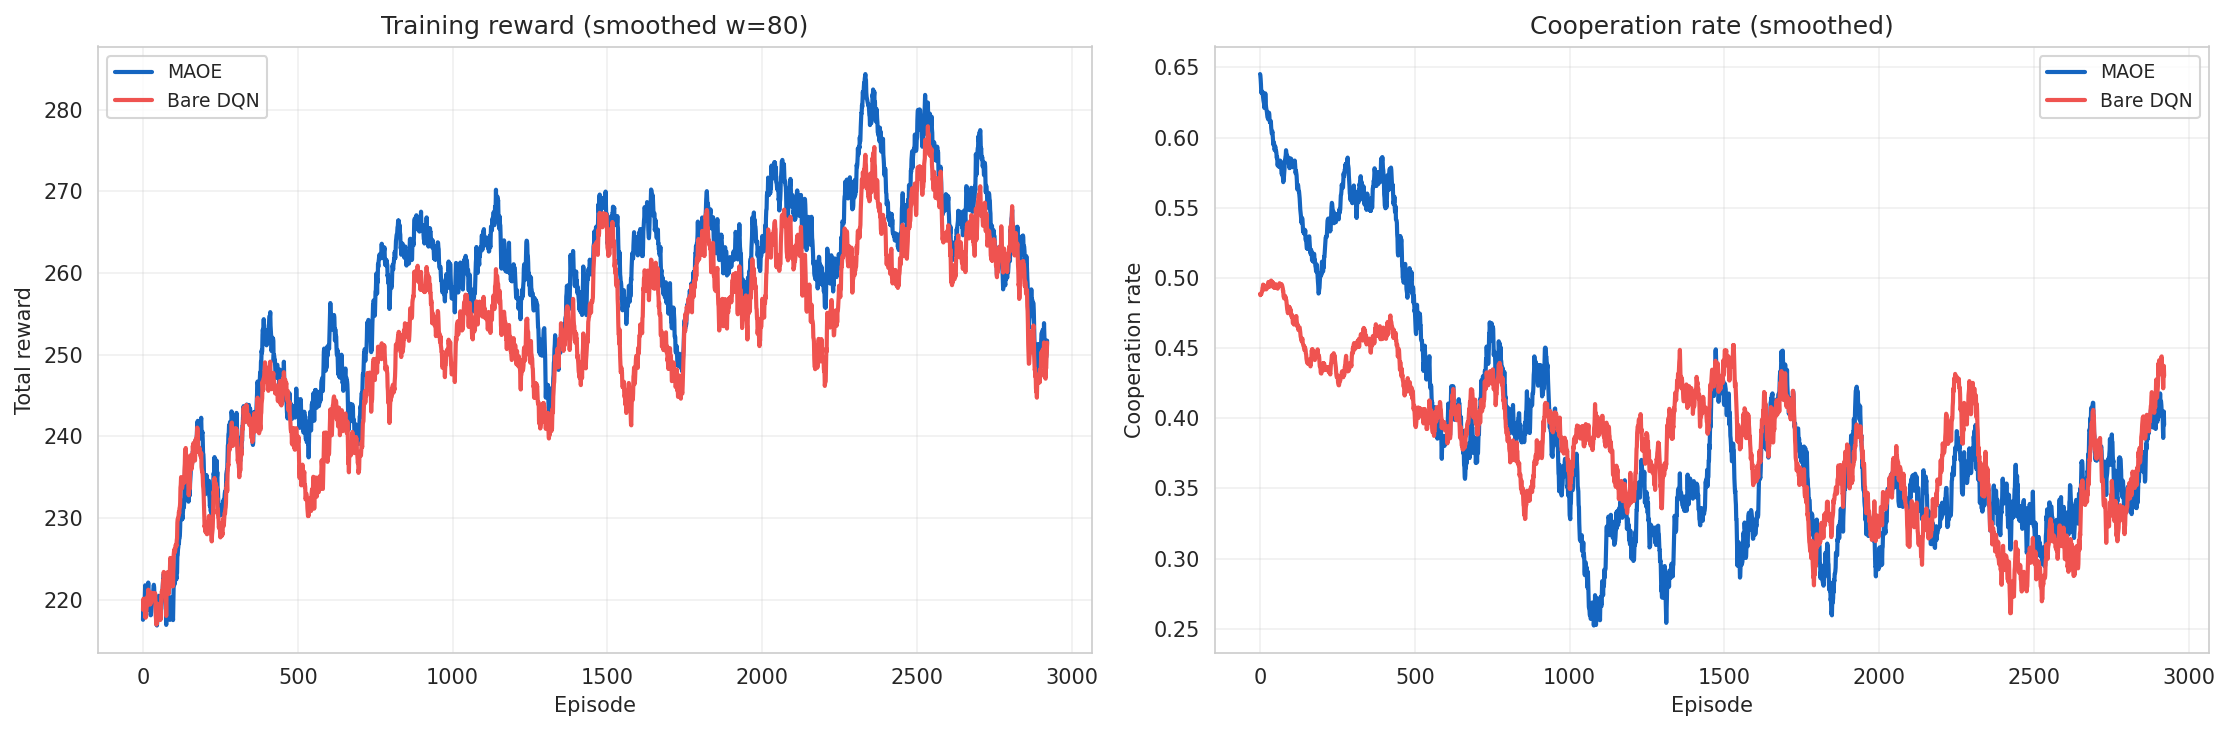

  Saved → 01_training_curves.png

───────────────────────────────────────────────────────
  Per-Round Adaptation
───────────────────────────────────────────────────────


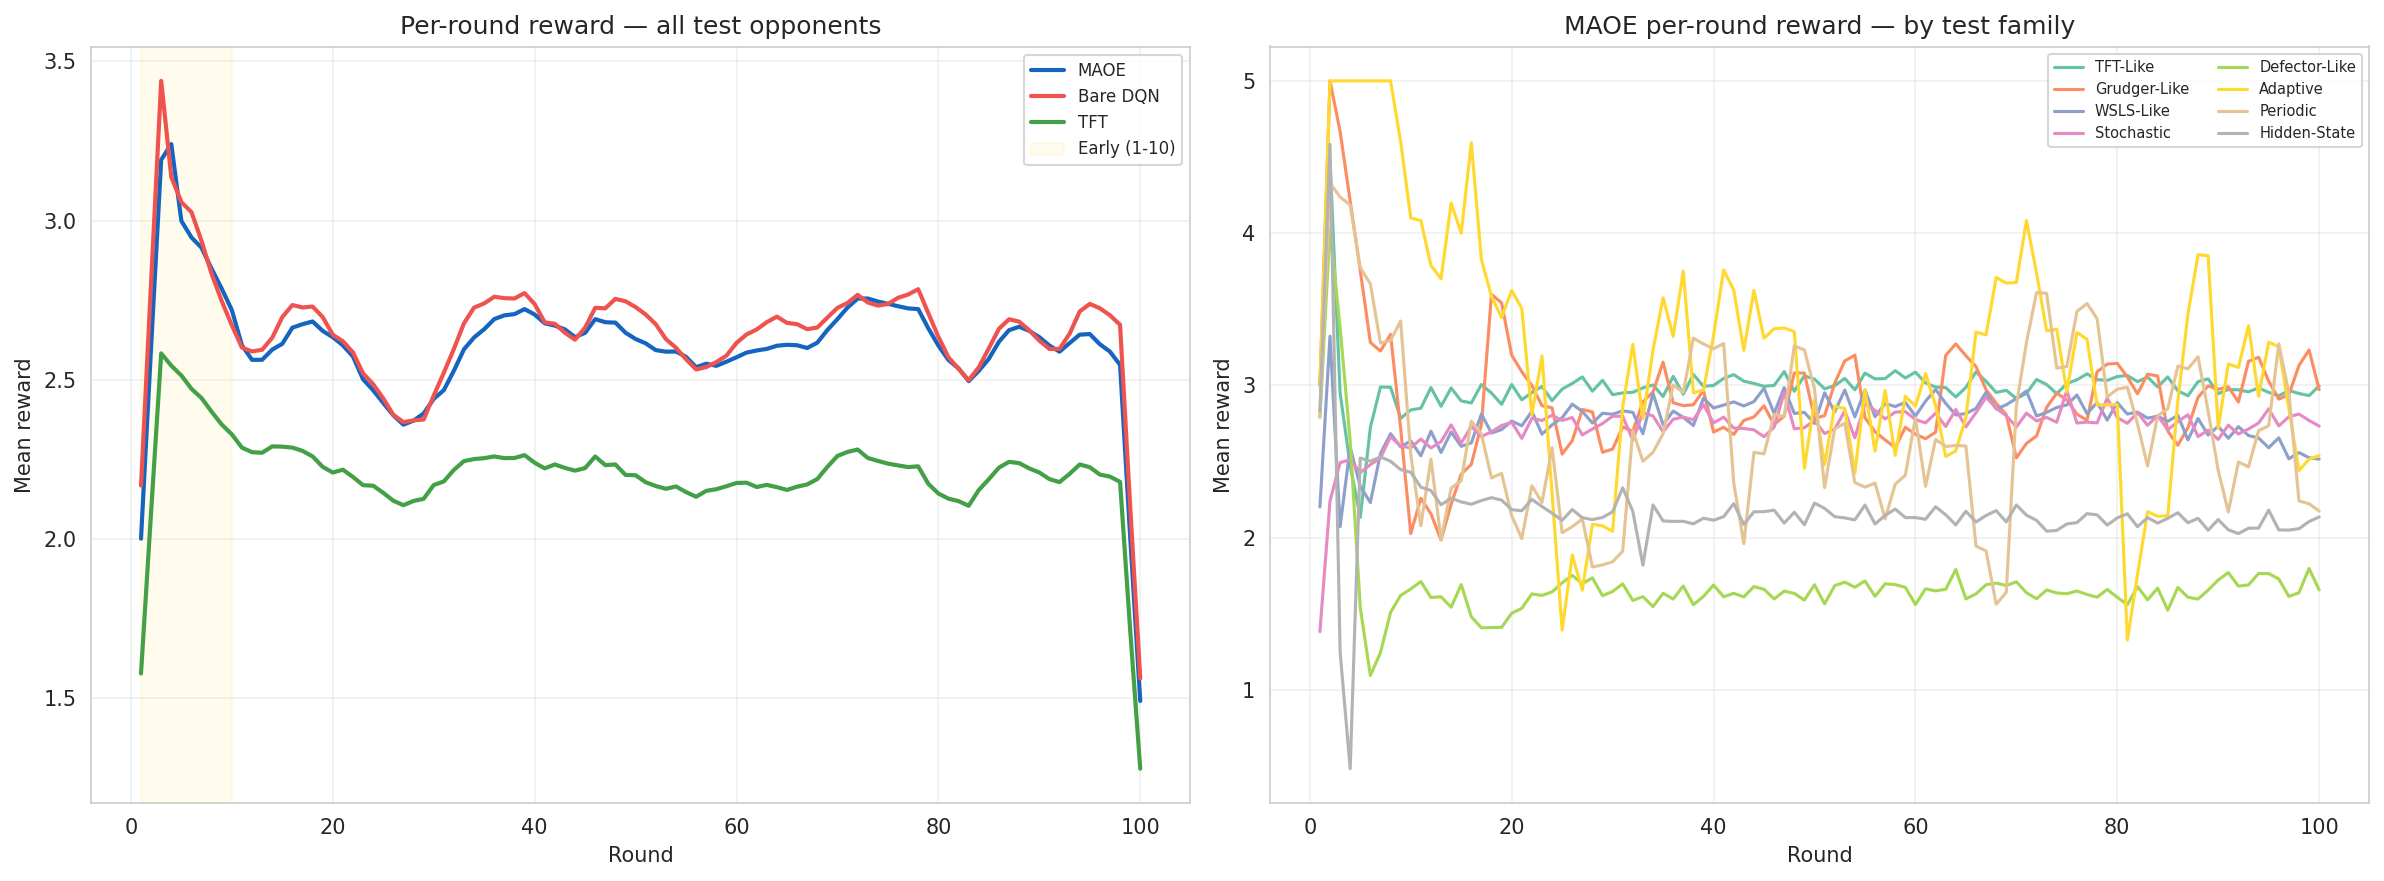

  Saved → 02_per_round_adaptation.png

───────────────────────────────────────────────────────
  Per-Family Generalization Score
───────────────────────────────────────────────────────


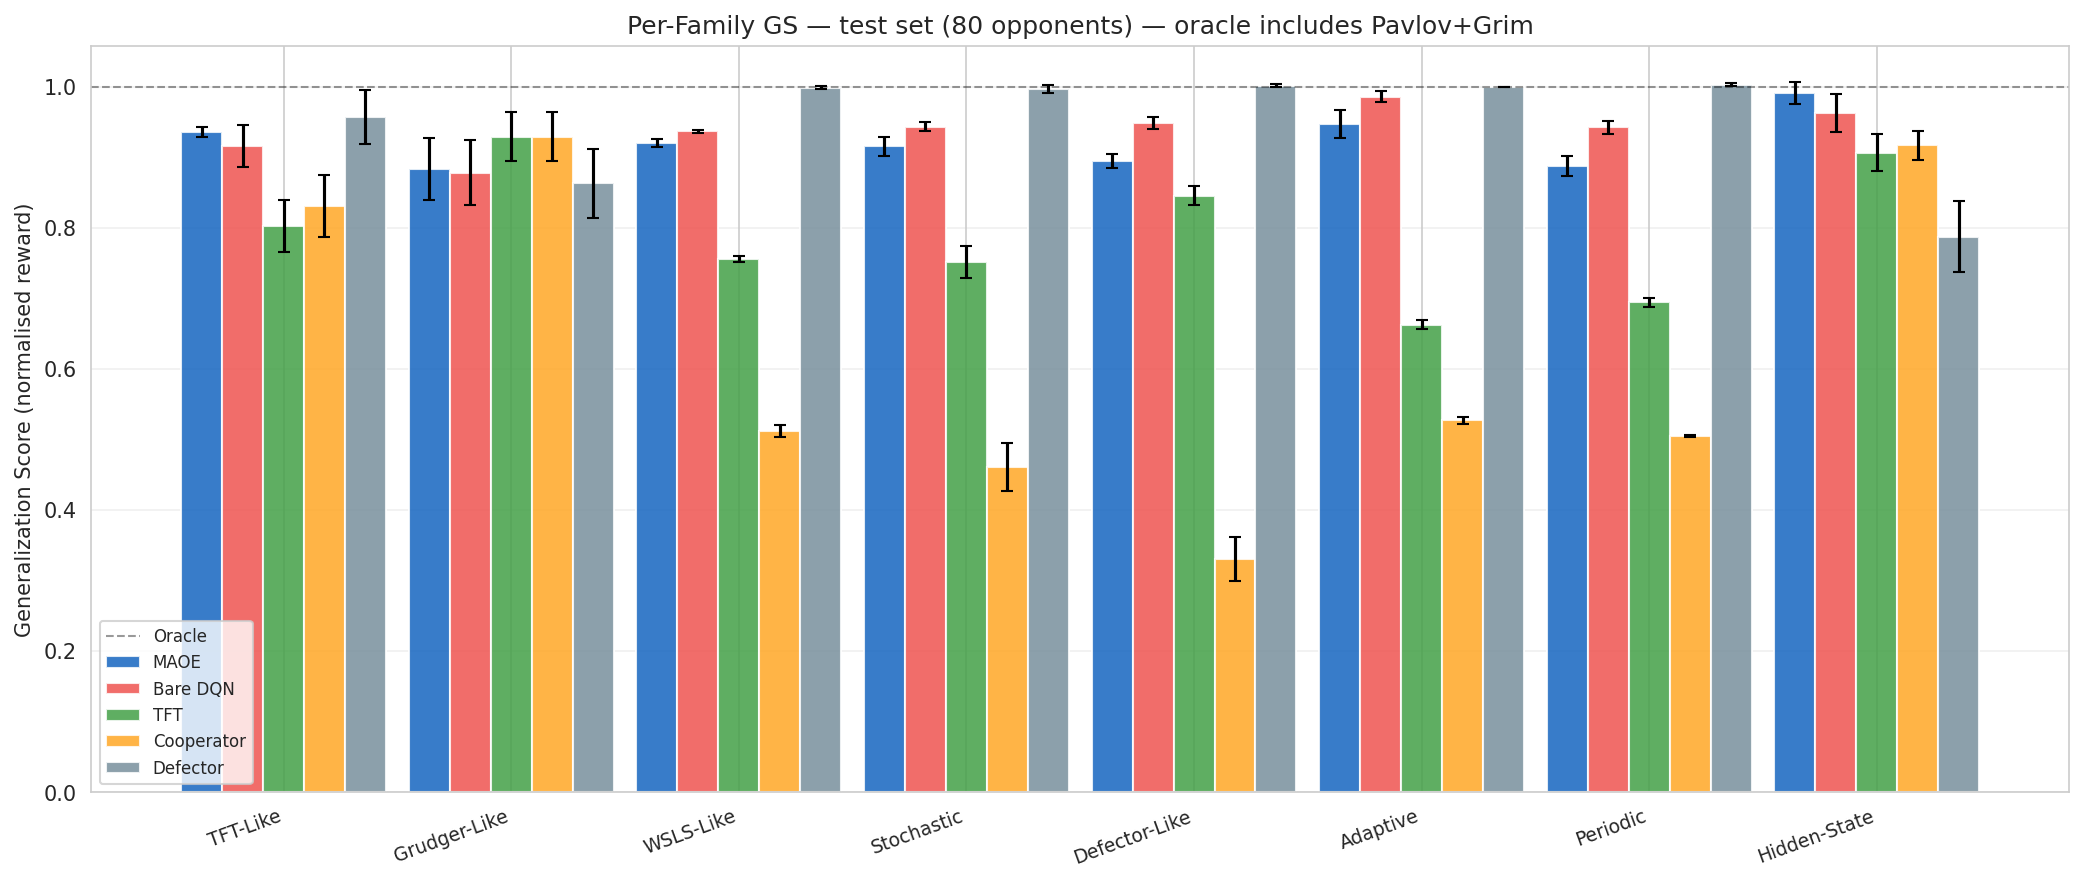

  Saved → 03_per_family_gs.png

───────────────────────────────────────────────────────
  Adaptation AUC
───────────────────────────────────────────────────────


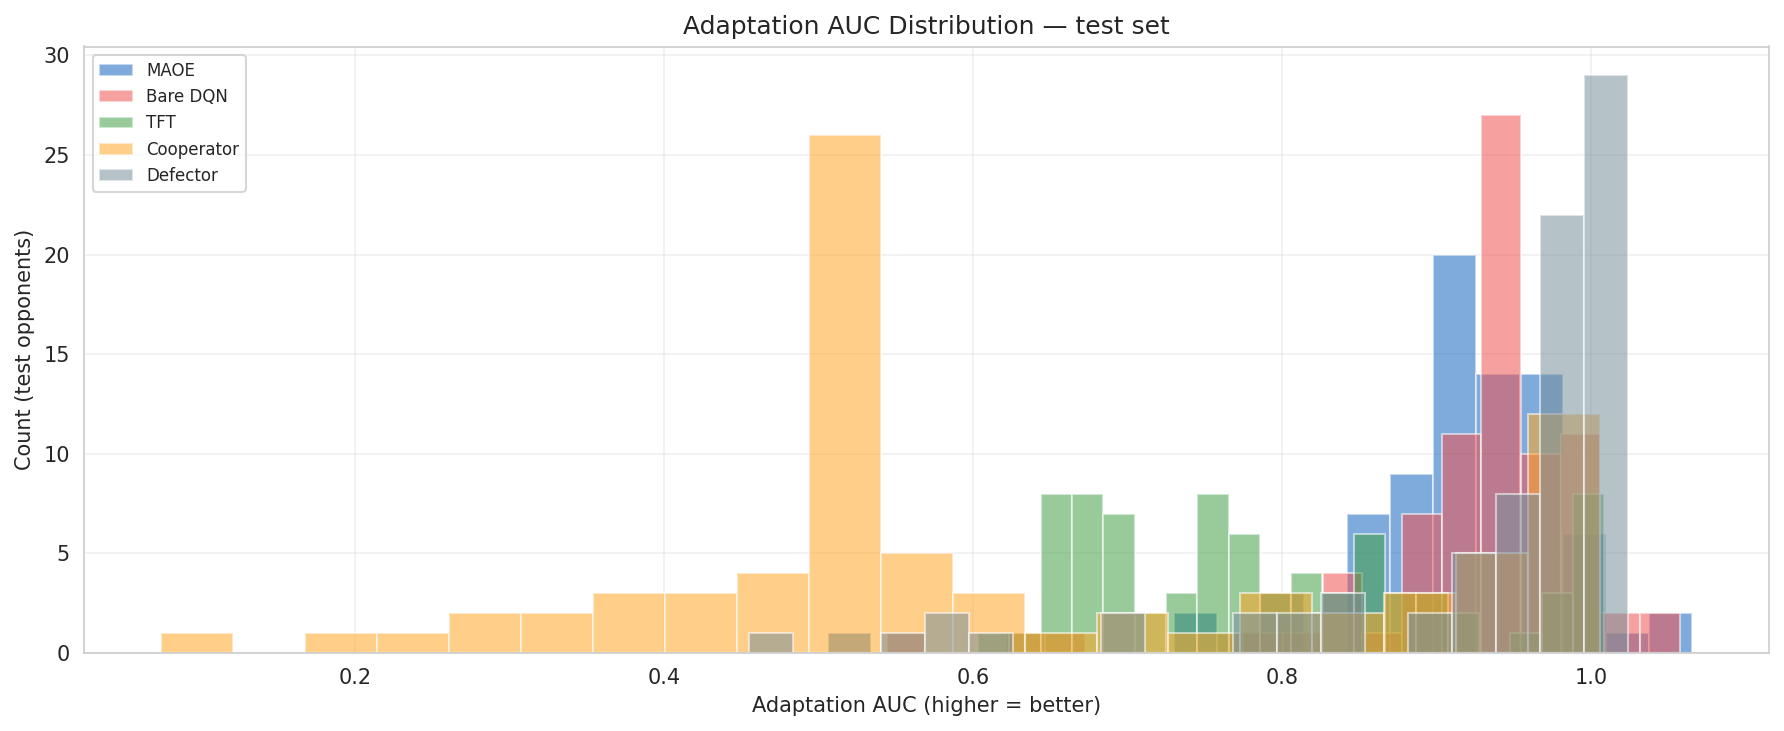

  Saved → 04_adaptation_auc.png

───────────────────────────────────────────────────────
  t-SNE Embeddings
───────────────────────────────────────────────────────


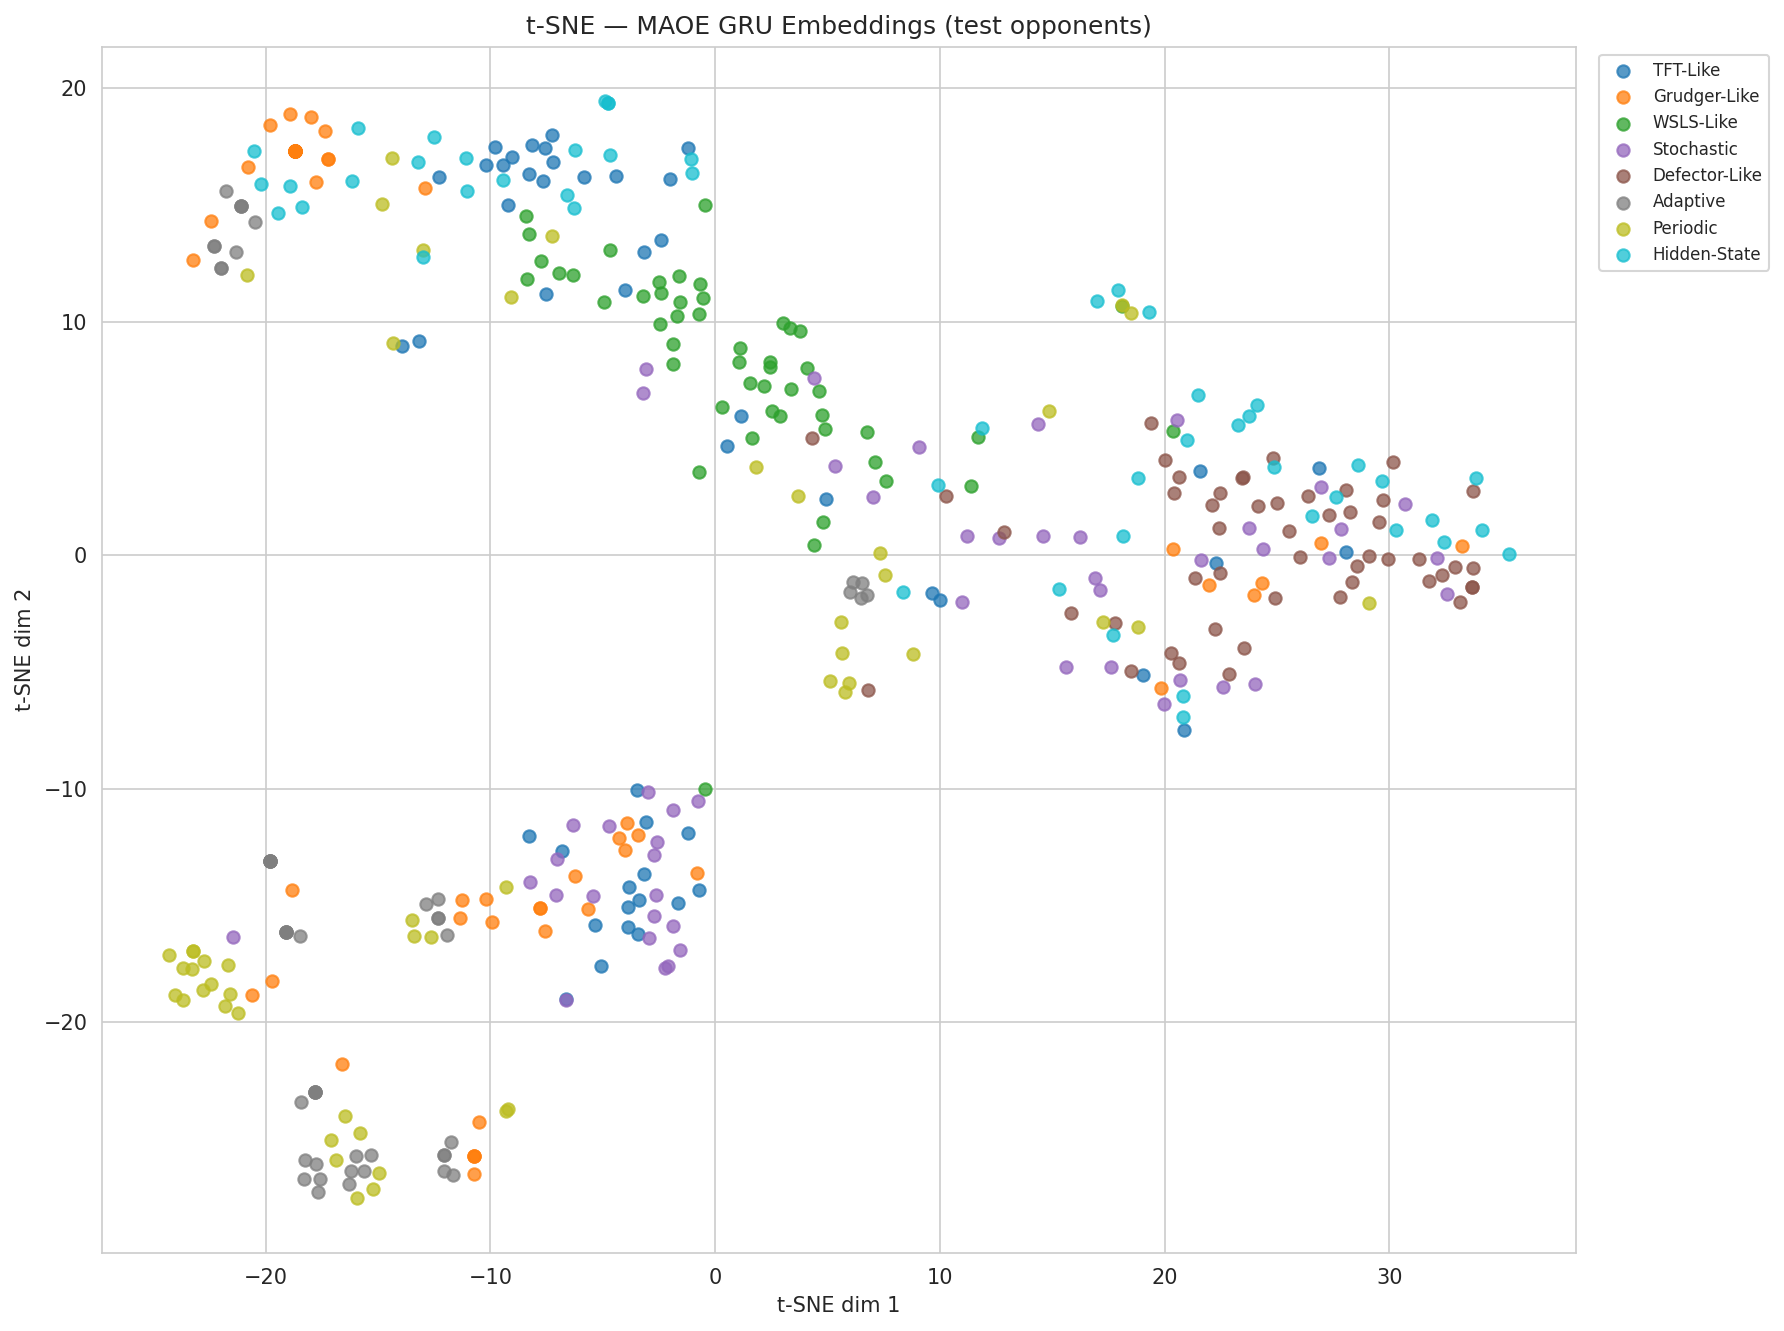

  Saved → 05_tsne_embeddings.png

  Saved → /kaggle/working/maoe_v2_results.json

[DONE] Total runtime: 80.3 minutes


In [2]:
"""
MAOE v2 — Simplified Architecture
===================================
Changes from v1:
  - REMOVED: opponent identity classification loss (lambda_opp) — was memorizing
    train identities, hurting OOD generalisation
  - REMOVED: supervised trait regression loss (lambda_trait) — noisy mid-episode
    labels, correlated axes (forgiveness ≈ 1-retaliation), competed with predictor
  - REMOVED: BehavioralTraitEncoder (trait head + opp head) — replaced by direct
    z→routing projection
  - SIMPLIFIED: expert routing now learned directly from z (linear + softmax),
    not via predicted trait intermediates
  - KEPT: OpponentPredictor (BCE on next opp action) — only loss grounded in a
    forward-prediction objective that generalises OOD
  - KEPT: InfoNCE contrastive loss — but positives are now guaranteed per batch
    using episode-start pairs rather than within-batch same-opp search
  - FIXED: oracle now includes Pavlov/WSLS as a candidate policy
  - FIXED: adaptation speed now uses AUC of per-round reward curve (normalised
    by oracle steady-state), not a fragile threshold-crossing
  - FIXED: per-family GS table starred column is now highest-mean, not
    highest-absolute (so Defector's inflated GS on trivial families is visible)
"""

import os, copy, time, json, random
from collections import deque, namedtuple
from dataclasses import dataclass
from typing import List, Tuple, Dict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from scipy.stats import wilcoxon
from tqdm import tqdm

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    _HAS_MPL = True
except ImportError:
    _HAS_MPL = False

try:
    from IPython.display import display, Image as IPImage
    _IN_NOTEBOOK = True
except ImportError:
    _IN_NOTEBOOK = False

# ─────────────────────────────────────────────────────────────────────────────
# CONSTANTS
# ─────────────────────────────────────────────────────────────────────────────
C, D = 0, 1
PAYOFF = {(C, C): 3, (C, D): 0, (D, C): 5, (D, D): 1}
ROUNDS_PER_EPISODE = 100
ACTION_DIM   = 2
GRU_INPUT_DIM  = 2
GRU_HIDDEN_DIM = 64
HISTORY_LEN    = 30
N_EXPERTS      = 3
SEED           = 42

FAMILY_NAMES = [
    'TFT-Like', 'Grudger-Like', 'WSLS-Like', 'Stochastic',
    'Defector-Like', 'Adaptive', 'Periodic', 'Hidden-State',
]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ─────────────────────────────────────────────────────────────────────────────
# STRATEGY CLASSES  (same as v1 — keep your existing implementations)
# ─────────────────────────────────────────────────────────────────────────────
# ... (paste / import your Strategy base class and all opponent strategies here)
# build_opponent_split() should also be imported / pasted here unchanged.


# ─────────────────────────────────────────────────────────────────────────────
# STATE ENCODER  (unchanged from v1)
# ─────────────────────────────────────────────────────────────────────────────
class StateEncoder:
    @staticmethod
    def encode(player_history, opponent_history, round_num):
        last_2_self  = ([0]*2 + player_history[-2:])[-2:]   if player_history   else [0,0]
        last_2_opp   = ([0]*2 + opponent_history[-2:])[-2:] if opponent_history else [0,0]
        last_5_self  = ([0]*5 + player_history[-5:])[-5:]   if player_history   else [0]*5
        last_5_opp   = ([0]*5 + opponent_history[-5:])[-5:] if opponent_history else [0]*5
        n = max(1, round_num)
        coop_self        = sum(1-a for a in player_history)   / n
        coop_opp         = sum(1-a for a in opponent_history) / n
        recent_self      = player_history[-10:]   if player_history   else []
        recent_opp       = opponent_history[-10:] if opponent_history else []
        coop_self_recent = sum(1-a for a in recent_self) / max(1, len(recent_self))
        coop_opp_recent  = sum(1-a for a in recent_opp)  / max(1, len(recent_opp))
        mutual_coop = sum(1 for a,o in zip(player_history, opponent_history)
                          if a == C and o == C) / n
        streak = 0
        for a in reversed(opponent_history):
            if a == D: streak += 1
            else: break
        streak_feat = min(streak, 10) / 10.0
        progress = round_num / ROUNDS_PER_EPISODE

        def coop_after(actions, shift=1):
            resp = [1 - opponent_history[t+shift]
                    for t, a in enumerate(actions)
                    if a == D and t+shift < len(opponent_history)]
            return np.mean(resp) if resp else 0.5

        coop_after_self_def  = coop_after(player_history)
        coop_after_self_coop = coop_after([a for a in player_history if a == C])
        ever_forgave = float(any(opponent_history[t+1] == C
                                 for t,a in enumerate(player_history)
                                 if a == D and t+1 < len(opponent_history)))
        hard_tft_signal = 0.0
        if len(opponent_history) >= 3 and len(player_history) >= 3:
            hard_tft_signal = float(player_history[-2]==D and player_history[-3]==D
                                    and opponent_history[-1]==D)
        first_defect   = float(len(opponent_history)>0 and opponent_history[0]==D)
        prober_pattern = 0.0
        if len(opponent_history) >= 3:
            prober_pattern = float(opponent_history[0]==D and opponent_history[1]==C
                                   and opponent_history[2]==C)
        early_def_rate = sum(opponent_history[:5]) / max(1, min(5, len(opponent_history)))
        is_prober_likely = 0.0
        if round_num >= 4:
            late_opp = opponent_history[3:]
            is_prober_likely = float(
                sum(late_opp)/max(1,len(late_opp)) > 0.7 and prober_pattern > 0.5)
        defection_after_coop = 1.0 - coop_after_self_coop

        features = (last_2_self + last_2_opp + last_5_self + last_5_opp +
                    [coop_self, coop_opp, coop_self_recent, coop_opp_recent,
                     mutual_coop, streak_feat, progress, progress**2,
                     coop_after_self_def, coop_after_self_coop,
                     ever_forgave, hard_tft_signal,
                     first_defect, prober_pattern, early_def_rate, is_prober_likely,
                     defection_after_coop])
        return np.array(features, dtype=np.float32)

STATE_DIM = 31


# ─────────────────────────────────────────────────────────────────────────────
# ENVIRONMENT  (unchanged)
# ─────────────────────────────────────────────────────────────────────────────
class IPDEnvironment:
    def __init__(self, opponent_strategy, family_name="unknown"):
        self._strategy_instance = opponent_strategy
        self.family_name = family_name
        self.reset()

    def reset(self):
        self.opponent = copy.deepcopy(self._strategy_instance)
        if hasattr(self.opponent, 'reset'): self.opponent.reset()
        self.player_history   = []
        self.opponent_history = []
        self.round = 0
        return self._get_obs()

    def step(self, player_action):
        opp_action = self.opponent.move(self.opponent_history[:], self.player_history[:])
        reward = PAYOFF[(player_action, opp_action)]
        self.player_history.append(player_action)
        self.opponent_history.append(opp_action)
        self.round += 1
        done = self.round >= ROUNDS_PER_EPISODE
        return self._get_obs(), reward, done, {'opponent_action': opp_action}

    def _get_obs(self):
        return StateEncoder.encode(self.player_history, self.opponent_history, self.round)


# ─────────────────────────────────────────────────────────────────────────────
# MAOE v2 NEURAL ARCHITECTURE
#
# Removed:  BehavioralTraitEncoder (trait + opp-id heads)
# Changed:  routing now = Linear(z_dim → n_experts) + Softmax  (direct, stable)
# Kept:     OpponentEncoder (GRU), OpponentPredictor, ExpertQNetwork
# ─────────────────────────────────────────────────────────────────────────────

class OpponentEncoder(nn.Module):
    """GRU: (action_t, opp_action_t) sequence → latent z."""
    def __init__(self, input_dim=GRU_INPUT_DIM, hidden_dim=GRU_HIDDEN_DIM, num_layers=2):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers=num_layers,
                          batch_first=True,
                          dropout=0.1 if num_layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden_dim)

    def forward(self, seq: torch.Tensor) -> torch.Tensor:   # seq: (B, T, 2)
        _, h = self.gru(seq)
        return self.norm(h[-1])                             # (B, hidden_dim)


class OpponentPredictor(nn.Module):
    """
    BCE auxiliary head: P(opp_next = C | z).
    This is the only supervised signal on the encoder.  It forces the GRU to
    learn *policy structure* (what the opponent will do) rather than identity.
    """
    def __init__(self, z_dim=GRU_HIDDEN_DIM):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(z_dim, 32), nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.head(z).squeeze(-1)   # (B,) in [0,1]


class ExpertQNetwork(nn.Module):
    """Dueling DQN head. Input: [state ‖ z]."""
    def __init__(self, state_dim, z_dim, action_dim=ACTION_DIM, hidden=128):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(state_dim + z_dim, hidden), nn.LayerNorm(hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
        )
        self.value_head = nn.Linear(hidden, 1)
        self.adv_head   = nn.Linear(hidden, action_dim)
        nn.init.zeros_(self.adv_head.weight)
        self.adv_head.bias.data = torch.tensor([0.3, -0.3])

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.shared(x)
        V = self.value_head(h)
        A = self.adv_head(h)
        return V + A - A.mean(dim=-1, keepdim=True)


class MAOENetwork(nn.Module):
    """
    Simplified MAOE:

        z           = GRU(history)                         encoder
        routing     = Softmax(Linear(z))                   direct z→gates (no trait intermediary)
        opp_pred    = Sigmoid(MLP(z))                      predictor head
        Q_k         = DuelingDQN_k([state, z])             k experts
        Q_final     = Σ_k routing_k * Q_k
    """
    def __init__(self, state_dim=STATE_DIM, z_dim=GRU_HIDDEN_DIM,
                 n_experts=N_EXPERTS, action_dim=ACTION_DIM, expert_hidden=128):
        super().__init__()
        self.encoder   = OpponentEncoder(GRU_INPUT_DIM, z_dim)
        self.predictor = OpponentPredictor(z_dim)

        # Direct z → routing weights (replaces trait_to_routing ∘ trait_head)
        self.routing_head = nn.Sequential(
            nn.Linear(z_dim, n_experts),
            nn.Softmax(dim=-1)
        )
        self.experts = nn.ModuleList([
            ExpertQNetwork(state_dim, z_dim, action_dim, expert_hidden)
            for _ in range(n_experts)
        ])
        self.n_experts = n_experts

    def forward(self, state: torch.Tensor, history_seq: torch.Tensor):
        """
        Returns:
          q_final:         (B, A)
          routing_weights: (B, n_experts)
          z:               (B, z_dim)
          opp_pred:        (B,)   P(opp_next=C)
        """
        z               = self.encoder(history_seq)           # (B, z_dim)
        routing_weights = self.routing_head(z)                # (B, n_experts)
        opp_pred        = self.predictor(z)                   # (B,)

        expert_input = torch.cat([state, z], dim=-1)          # (B, state+z)
        q_stack = torch.stack(
            [exp(expert_input) for exp in self.experts], dim=1
        )                                                     # (B, n_experts, A)
        q_final = (routing_weights.unsqueeze(-1) * q_stack).sum(dim=1)  # (B, A)

        return q_final, routing_weights, z, opp_pred

    def encode(self, history_seq: torch.Tensor) -> torch.Tensor:
        return self.encoder(history_seq)


# ─────────────────────────────────────────────────────────────────────────────
# REPLAY BUFFER
# ─────────────────────────────────────────────────────────────────────────────
MAOETransition = namedtuple('MAOETransition', [
    'state', 'history_seq', 'action', 'reward',
    'next_state', 'next_history_seq', 'done',
    'opp_idx', 'next_opp_action',
    'ep_start_seq',   # sequence from start of episode — used as contrastive positive
])

class ReplayBuffer:
    def __init__(self, capacity=80_000):
        self.buffer = deque(maxlen=capacity)

    def push(self, *args):
        self.buffer.append(MAOETransition(*args))

    def sample(self, batch_size):
        return MAOETransition(*zip(*random.sample(self.buffer, batch_size)))

    def __len__(self): return len(self.buffer)


class ContrastiveBuffer:
    """
    Stores (seq, opp_idx) pairs for negative sampling in InfoNCE.
    Positives come from the ep_start_seq field in the replay batch,
    guaranteeing a same-opponent anchor↔positive pairing every update.
    """
    def __init__(self, capacity=8_000):
        self.seqs    = deque(maxlen=capacity)
        self.opp_ids = deque(maxlen=capacity)

    def push(self, seq, opp_idx):
        self.seqs.append(seq)
        self.opp_ids.append(opp_idx)

    def sample_negatives(self, anchor_opp, n):
        candidates = [s for s, o in zip(self.seqs, self.opp_ids) if o != anchor_opp]
        if len(candidates) < n: return None
        return np.array(random.sample(candidates, n), dtype=np.float32)

    def __len__(self): return len(self.seqs)


# ─────────────────────────────────────────────────────────────────────────────
# CONTRASTIVE LOSS (InfoNCE)
# ─────────────────────────────────────────────────────────────────────────────
def info_nce_loss(anchor, positive, negatives, temperature=0.07):
    anchor    = F.normalize(anchor,    dim=-1)
    positive  = F.normalize(positive,  dim=-1)
    negatives = F.normalize(negatives, dim=-1)
    pos_sim   = (anchor * positive).sum(-1, keepdim=True) / temperature
    neg_sim   = torch.bmm(negatives, anchor.unsqueeze(-1)).squeeze(-1) / temperature
    logits    = torch.cat([pos_sim, neg_sim], dim=-1)
    labels    = torch.zeros(anchor.shape[0], dtype=torch.long, device=anchor.device)
    return F.cross_entropy(logits, labels)


# ─────────────────────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────────────────────
@dataclass
class MAOEConfig:
    z_dim:         int   = GRU_HIDDEN_DIM
    expert_hidden: int   = 128
    history_len:   int   = HISTORY_LEN

    lr:            float = 3e-4
    gamma:         float = 0.98
    batch_size:    int   = 256
    target_update_freq: int = 10
    train_freq:    int   = 4
    buffer_size:   int   = 80_000
    min_buffer:    int   = 1_000

    eps_start:     float = 0.5
    eps_end:       float = 0.02
    eps_decay_ep:  int   = 600

    # Two losses only
    lambda_predict:  float = 0.30   # BCE on next opp action
    lambda_contrast: float = 0.15   # InfoNCE contrastive
    n_negatives:     int   = 8
    contrast_temp:   float = 0.07

    seed: int = SEED


# ─────────────────────────────────────────────────────────────────────────────
# MAOE AGENT v2
# ─────────────────────────────────────────────────────────────────────────────
class MAOEAgent:
    name = "MAOE"

    def __init__(self, config: MAOEConfig = None):
        self.config = config or MAOEConfig()
        self._rng   = random.Random(self.config.seed)
        self.total_episodes = 0
        self.steps = 0

        self.policy_net = MAOENetwork(
            STATE_DIM, self.config.z_dim, N_EXPERTS,
            ACTION_DIM, self.config.expert_hidden
        ).to(device)
        self.target_net = MAOENetwork(
            STATE_DIM, self.config.z_dim, N_EXPERTS,
            ACTION_DIM, self.config.expert_hidden
        ).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(
            self.policy_net.parameters(), lr=self.config.lr, weight_decay=1e-5
        )
        self.scheduler = optim.lr_scheduler.CosineAnnealingLR(
            self.optimizer, T_max=2000, eta_min=1e-5
        )

        self.replay     = ReplayBuffer(self.config.buffer_size)
        self.con_buffer = ContrastiveBuffer()

        self._reset_episode_state()

    def _reset_episode_state(self):
        self._interaction_history: List[Tuple[int,int]] = []
        self._current_opp_idx = 0
        self._round_in_ep     = 0
        self._ep_start_seq    = None   # set after first HISTORY_LEN steps

    @property
    def epsilon(self):
        return self.config.eps_end + (self.config.eps_start - self.config.eps_end) * \
               max(0.0, 1.0 - self.total_episodes / self.config.eps_decay_ep)

    def _build_history_seq(self, history):
        T    = self.config.history_len
        hist = history[-T:]
        pad  = [(0, 0)] * (T - len(hist))
        return np.array(pad + list(hist), dtype=np.float32)

    def select_action(self, state, eval_mode=False):
        if self._round_in_ep == 0: return C
        if not eval_mode and self._rng.random() < self.epsilon:
            return self._rng.randint(0, ACTION_DIM - 1)
        seq   = self._build_history_seq(self._interaction_history)
        seq_t = torch.tensor(seq,   dtype=torch.float32).unsqueeze(0).to(device)
        st_t  = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            q_final, _, _, _ = self.policy_net(st_t, seq_t)
        return int(q_final.argmax(dim=-1).item())

    def push(self, state, action, reward, next_state, done, next_opp_action):
        seq      = self._build_history_seq(self._interaction_history[:-1])
        next_seq = self._build_history_seq(self._interaction_history)

        # Contrastive positive: a short sequence from the start of this episode.
        # Guaranteed to be from the same opponent — no within-batch search needed.
        if self._ep_start_seq is None and len(self._interaction_history) >= 10:
            self._ep_start_seq = self._build_history_seq(
                self._interaction_history[:10]
            )
        ep_start = (self._ep_start_seq if self._ep_start_seq is not None
                    else seq)

        self.replay.push(
            state, seq, action, reward,
            next_state, next_seq, float(done),
            self._current_opp_idx,
            float(next_opp_action),
            ep_start,
        )

    def train_step(self):
        if len(self.replay) < self.config.min_buffer:
            return {}

        batch = self.replay.sample(self.config.batch_size)
        B     = self.config.batch_size

        ST    = torch.tensor(np.array(batch.state),             dtype=torch.float32).to(device)
        SEQ   = torch.tensor(np.array(batch.history_seq),       dtype=torch.float32).to(device)
        A     = torch.tensor(batch.action,                       dtype=torch.long).to(device)
        R     = torch.tensor(batch.reward,                       dtype=torch.float32).to(device)
        NST   = torch.tensor(np.array(batch.next_state),         dtype=torch.float32).to(device)
        NSEQ  = torch.tensor(np.array(batch.next_history_seq),   dtype=torch.float32).to(device)
        DN    = torch.tensor(batch.done,                          dtype=torch.float32).to(device)
        NOPP  = torch.tensor(batch.next_opp_action,               dtype=torch.float32).to(device)
        EPSEQ = torch.tensor(np.array(batch.ep_start_seq),        dtype=torch.float32).to(device)

        # ── Forward ───────────────────────────────────────────────────────────
        q_pred, _, z_anchor, opp_pred = self.policy_net(ST, SEQ)
        q_vals = q_pred.gather(1, A.unsqueeze(1)).squeeze(1)

        # ── Double DQN target ─────────────────────────────────────────────────
        with torch.no_grad():
            q_next_pol, _, _, _ = self.policy_net(NST, NSEQ)
            next_acts = q_next_pol.argmax(dim=1)
            q_next_tgt, _, _, _ = self.target_net(NST, NSEQ)
            q_next  = q_next_tgt.gather(1, next_acts.unsqueeze(1)).squeeze(1)
            targets = R + self.config.gamma * q_next * (1 - DN)

        td_loss = F.smooth_l1_loss(q_vals, targets)

        # ── Opponent action prediction (BCE) ──────────────────────────────────
        # NOPP: 0=C, 1=D → predict P(C) = 1 - NOPP
        predict_loss = F.binary_cross_entropy(opp_pred, 1.0 - NOPP)

        # ── InfoNCE contrastive ───────────────────────────────────────────────
        # Positive = ep_start_seq (same opponent, guaranteed).
        # Negatives sampled from ContrastiveBuffer (different opponents).
        contrast_loss = torch.tensor(0.0, device=device)
        if len(self.con_buffer) > self.config.n_negatives * 4:
            opp_ids_list = list(batch.opp_idx)
            neg_seqs = []
            valid_idx = []
            for i, opp_id in enumerate(opp_ids_list[:min(B, 64)]):
                negs = self.con_buffer.sample_negatives(
                    opp_id, self.config.n_negatives)
                if negs is not None:
                    neg_seqs.append(negs)
                    valid_idx.append(i)

            if neg_seqs:
                B_con = len(neg_seqs)
                K     = self.config.n_negatives
                neg_t = torch.tensor(
                    np.array(neg_seqs), dtype=torch.float32
                ).to(device).view(B_con * K, HISTORY_LEN, 2)

                with torch.no_grad():
                    z_pos = self.policy_net.encode(EPSEQ[valid_idx])
                    z_neg = self.policy_net.encode(neg_t).view(B_con, K, -1)

                contrast_loss = info_nce_loss(
                    z_anchor[valid_idx], z_pos, z_neg,
                    temperature=self.config.contrast_temp
                )

        # ── Total loss ─────────────────────────────────────────────────────────
        total_loss = (td_loss
                      + self.config.lambda_predict  * predict_loss
                      + self.config.lambda_contrast * contrast_loss)

        self.optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), 1.0)
        self.optimizer.step()

        self.steps += 1
        if self.steps % self.config.target_update_freq == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

        return {
            'loss':          td_loss.item(),
            'predict_loss':  predict_loss.item(),
            'contrast_loss': float(contrast_loss),
            'total_loss':    total_loss.item(),
        }

    def on_episode_start(self):
        self.total_episodes += 1
        self._reset_episode_state()

    def on_episode_end(self):
        if len(self._interaction_history) >= 5:
            seq = self._build_history_seq(self._interaction_history)
            self.con_buffer.push(seq, self._current_opp_idx)

    def on_step(self, action, opp_action, opp_idx=0):
        self._interaction_history.append((action, opp_action))
        self._current_opp_idx = opp_idx
        self._round_in_ep += 1

    def build_state(self, base_obs): return base_obs

    @property
    def epsilon_val(self): return self.epsilon


# ─────────────────────────────────────────────────────────────────────────────
# BASELINE AGENTS  (unchanged)
# ─────────────────────────────────────────────────────────────────────────────
class BareDQNNet(nn.Module):
    def __init__(self, state_dim, action_dim, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.LayerNorm(hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),    nn.LayerNorm(hidden), nn.ReLU(),
            nn.Linear(hidden, hidden//2), nn.LayerNorm(hidden//2), nn.ReLU(),
        )
        self.value_head = nn.Linear(hidden//2, 1)
        self.adv_head   = nn.Linear(hidden//2, action_dim)

    def forward(self, x):
        h = self.net(x)
        V = self.value_head(h)
        A = self.adv_head(h)
        return V + A - A.mean(dim=-1, keepdim=True)

Transition = namedtuple('Transition', ('state','action','reward','next_state','done'))

class BareDQNAgent:
    name = "Bare DQN"
    def __init__(self, hidden=256, lr=1e-3, gamma=0.98, batch_size=256,
                 target_update_freq=10, eps_start=1.0, eps_end=0.05,
                 eps_decay=500, buffer_size=50_000, seed=SEED):
        self.gamma=gamma; self.batch_size=batch_size
        self.eps_start=eps_start; self.eps_end=eps_end; self.eps_decay=eps_decay
        self.episode_num=0; self._rng=random.Random(seed)
        self.policy_net = BareDQNNet(STATE_DIM, ACTION_DIM, hidden).to(device)
        self.target_net = BareDQNNet(STATE_DIM, ACTION_DIM, hidden).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()
        self.opt    = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.buffer = deque(maxlen=buffer_size)
        self.target_freq=target_update_freq; self.steps=0

    @property
    def epsilon(self):
        return self.eps_end + (self.eps_start-self.eps_end)*np.exp(-self.episode_num/self.eps_decay)

    def build_state(self, b): return b

    def select_action(self, state, eval_mode=False):
        if not eval_mode and self._rng.random() < self.epsilon:
            return self._rng.randint(0, ACTION_DIM-1)
        with torch.no_grad():
            t = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
            return int(self.policy_net(t).argmax(1).item())

    def push(self, state, action, reward, next_state, done, next_opp_action=0):
        self.buffer.append(Transition(state, action, reward, next_state, float(done)))

    def train_step(self):
        if len(self.buffer) < self.batch_size: return {}
        batch = Transition(*zip(*random.sample(list(self.buffer), self.batch_size)))
        S  = torch.tensor(np.array(batch.state),      dtype=torch.float32).to(device)
        A  = torch.tensor(batch.action,                dtype=torch.long).to(device)
        R  = torch.tensor(batch.reward,                dtype=torch.float32).to(device)
        S2 = torch.tensor(np.array(batch.next_state), dtype=torch.float32).to(device)
        Dn = torch.tensor(batch.done,                  dtype=torch.float32).to(device)
        q  = self.policy_net(S).gather(1, A.unsqueeze(1)).squeeze(1)
        with torch.no_grad():
            a2  = self.policy_net(S2).argmax(1)
            nq  = self.target_net(S2).gather(1, a2.unsqueeze(1)).squeeze(1)
            tgt = R + self.gamma * nq * (1-Dn)
        loss = F.smooth_l1_loss(q, tgt)
        self.opt.zero_grad(); loss.backward(); self.opt.step()
        self.steps += 1
        if self.steps % self.target_freq == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())
        return {'loss': loss.item()}

    def on_episode_start(self): self.episode_num += 1
    def on_episode_end(self): pass
    def on_step(self, action, opp_action, opp_idx=0): pass

class TFTAgent:
    name = "TFT"
    def __init__(self): self.last_opp = C
    def build_state(self, b): return b
    def select_action(self, s, eval_mode=False): return self.last_opp
    def push(self, *a, **kw): pass
    def train_step(self): return {}
    def on_episode_start(self): self.last_opp = C
    def on_episode_end(self): pass
    def on_step(self, a, o, opp_idx=0): self.last_opp = o
    @property
    def epsilon(self): return 0.0

class CooperatorAgent:
    name = "Cooperator"
    def build_state(self, b): return b
    def select_action(self, s, eval_mode=False): return C
    def push(self, *a, **kw): pass
    def train_step(self): return {}
    def on_episode_start(self): pass
    def on_episode_end(self): pass
    def on_step(self, a, o, opp_idx=0): pass
    @property
    def epsilon(self): return 0.0

class DefectorAgent:
    name = "Defector"
    def build_state(self, b): return b
    def select_action(self, s, eval_mode=False): return D
    def push(self, *a, **kw): pass
    def train_step(self): return {}
    def on_episode_start(self): pass
    def on_episode_end(self): pass
    def on_step(self, a, o, opp_idx=0): pass
    @property
    def epsilon(self): return 0.0


# ─────────────────────────────────────────────────────────────────────────────
# TRAINING LOOP  (unchanged interface)
# ─────────────────────────────────────────────────────────────────────────────
def run_training(agent, train_opponents, num_episodes=2000,
                 agent_name="Agent", seed=SEED):
    rng_ep = random.Random(seed)
    all_rewards, all_coops, losses = [], [], []
    round_reward_acc   = np.zeros(ROUNDS_PER_EPISODE)
    round_reward_count = np.zeros(ROUNDS_PER_EPISODE)

    train_freq = getattr(agent.config, 'train_freq', 4) if hasattr(agent, 'config') else 4
    n_train    = len(train_opponents)

    pbar = tqdm(range(1, num_episodes+1), desc=f"Training {agent_name}", unit="ep")
    for ep in pbar:
        opp_idx = rng_ep.randint(0, n_train-1)
        opp_strategy, fam_name, _ = train_opponents[opp_idx]
        env = IPDEnvironment(opp_strategy, family_name=fam_name)

        agent.on_episode_start()
        base_obs = env.reset()
        ep_r, ep_c = 0.0, 0
        ep_round_rewards = []

        for rnd in range(ROUNDS_PER_EPISODE):
            action = agent.select_action(base_obs)
            next_base, reward, done, info = env.step(action)
            opp_action = info['opponent_action']

            agent.on_step(action, opp_action, opp_idx=opp_idx)
            agent.push(base_obs, action, reward, next_base, done, next_opp_action=opp_action)

            if rnd % train_freq == 0:
                tr = agent.train_step()
                if tr and 'loss' in tr:
                    losses.append(tr['loss'])

            ep_r += reward
            ep_c += (1-action)
            ep_round_rewards.append(reward)
            base_obs = next_base
            if done: break

        agent.on_episode_end()
        if hasattr(agent, 'scheduler'): agent.scheduler.step()

        all_rewards.append(ep_r)
        all_coops.append(ep_c / ROUNDS_PER_EPISODE)
        for t, r in enumerate(ep_round_rewards):
            round_reward_acc[t]   += r
            round_reward_count[t] += 1

        if ep % 100 == 0:
            pbar.set_postfix({
                'R(100)': f'{np.mean(all_rewards[-100:]):.1f}',
                'coop':   f'{np.mean(all_coops[-100:]):.2f}',
                'eps':    f'{agent.epsilon:.3f}',
            })

    round_mean = np.where(round_reward_count > 0,
                          round_reward_acc / np.maximum(round_reward_count, 1), 0.0)
    return {
        'rewards':           np.array(all_rewards),
        'coop_rates':        np.array(all_coops),
        'losses':            losses,
        'round_reward_mean': round_mean,
    }


# ─────────────────────────────────────────────────────────────────────────────
# EVALUATION
# ─────────────────────────────────────────────────────────────────────────────
def evaluate_on_pool(agent, opponent_pool, num_eval_episodes=100, seed=SEED):
    results = {}
    for opp_idx, (opp_strategy, fam_name, params) in enumerate(opponent_pool):
        opp_name = f"{fam_name}/{opp_strategy.name}"
        ep_rewards, ep_coops = [], []
        round_r_acc = np.zeros(ROUNDS_PER_EPISODE)
        round_r_cnt = np.zeros(ROUNDS_PER_EPISODE)

        for _ in range(num_eval_episodes):
            env = IPDEnvironment(opp_strategy, family_name=fam_name)
            agent.on_episode_start()
            base_obs = env.reset()
            r_sum, coops = 0.0, 0

            for rnd in range(ROUNDS_PER_EPISODE):
                action = agent.select_action(base_obs, eval_mode=True)
                next_base, reward, done, info = env.step(action)
                opp_action = info['opponent_action']
                agent.on_step(action, opp_action, opp_idx=opp_idx)
                round_r_acc[rnd] += reward
                round_r_cnt[rnd] += 1
                r_sum  += reward
                coops  += (1-action)
                base_obs = next_base
                if done: break

            agent.on_episode_end()
            ep_rewards.append(r_sum)
            ep_coops.append(coops / ROUNDS_PER_EPISODE)

        round_mean = np.where(round_r_cnt > 0,
                              round_r_acc / np.maximum(round_r_cnt, 1), 0.0)
        results[opp_name] = {
            'avg_reward':   float(np.mean(ep_rewards)),
            'std_reward':   float(np.std(ep_rewards)),
            'coop_rate':    float(np.mean(ep_coops)),
            'round_reward': round_mean,
            'family':       fam_name,
            'all_rewards':  ep_rewards,
        }
    return results


# ─────────────────────────────────────────────────────────────────────────────
# ORACLE  — fixed: now includes Pavlov/WSLS as a candidate
# ─────────────────────────────────────────────────────────────────────────────
def _run_fixed_policy(opp_strategy, policy_fn, num_episodes, seed):
    """Run a fixed policy_fn(rnd, player_hist, opp_hist) → action."""
    rng = random.Random(seed)
    total = 0.0
    for _ in range(num_episodes):
        env = IPDEnvironment(opp_strategy)
        env.reset()
        ph, oh = [], []
        for rnd in range(ROUNDS_PER_EPISODE):
            act = policy_fn(rnd, ph, oh)
            _, reward, done, info = env.step(act)
            ph.append(act)
            oh.append(info['opponent_action'])
            total += reward
            if done: break
    return total / num_episodes

def compute_oracle_rewards(opponent_pool, num_episodes=50, seed=SEED):
    oracle_rewards = {}
    for opp_strategy, fam_name, params in opponent_pool:
        opp_name = f"{fam_name}/{opp_strategy.name}"
        candidates = []

        # Always-C
        candidates.append(_run_fixed_policy(
            opp_strategy, lambda r,ph,oh: C, num_episodes, seed))
        # Always-D
        candidates.append(_run_fixed_policy(
            opp_strategy, lambda r,ph,oh: D, num_episodes, seed))
        # TFT
        candidates.append(_run_fixed_policy(
            opp_strategy,
            lambda r,ph,oh: (C if not oh else oh[-1]),
            num_episodes, seed))
        # Pavlov (WSLS): cooperate if last round was (C,C) or (D,D)
        def pavlov(r, ph, oh):
            if not ph: return C
            if ph[-1] == oh[-1]: return C   # both same → cooperate
            return D
        candidates.append(_run_fixed_policy(
            opp_strategy, pavlov, num_episodes, seed))
        # Grim Trigger
        def grim(r, ph, oh):
            if any(o == D for o in oh): return D
            return C
        candidates.append(_run_fixed_policy(
            opp_strategy, grim, num_episodes, seed))

        oracle_rewards[opp_name] = max(candidates)
    return oracle_rewards


# ─────────────────────────────────────────────────────────────────────────────
# METRICS
# ─────────────────────────────────────────────────────────────────────────────
def compute_generalization_score(eval_results, oracle_rewards):
    gs = {}
    for opp_name, stats in eval_results.items():
        oracle = oracle_rewards.get(opp_name, stats['avg_reward'])
        gs[opp_name] = float(stats['avg_reward'] / max(oracle, 1.0))
    return gs


def compute_adaptation_speed_auc(eval_results, oracle_rewards):
    """
    AUC-based adaptation speed.

    For each opponent:
      - Compute the per-round reward curve (already averaged over eval episodes).
      - Normalise by the oracle reward / ROUNDS (gives a ~[0,1] target).
      - AUC = mean of normalised per-round rewards.
      - Higher AUC = faster/better adaptation (1.0 = oracle from round 1).

    Returns per-opponent AUC and mean across all opponents.
    This replaces the broken threshold-crossing metric.
    """
    auc_per_opp = {}
    for opp_name, stats in eval_results.items():
        curve  = stats['round_reward']                        # shape: (100,)
        oracle = oracle_rewards.get(opp_name, None)
        if oracle is None or oracle < 1.0:
            auc_per_opp[opp_name] = float(np.mean(curve)) / max(1.0, np.max(curve))
            continue
        per_round_oracle = oracle / ROUNDS_PER_EPISODE        # expected reward/round at oracle
        norm_curve = np.clip(curve / max(per_round_oracle, 0.01), 0.0, 1.5)
        auc_per_opp[opp_name] = float(np.mean(norm_curve))
    return auc_per_opp


def compute_per_family_gs(gs_dict, eval_results):
    family_gs = {fam: [] for fam in FAMILY_NAMES}
    for opp_name, gs_val in gs_dict.items():
        fam = eval_results[opp_name]['family']
        if fam in family_gs:
            family_gs[fam].append(gs_val)
    return {fam: float(np.mean(vals)) if vals else float('nan')
            for fam, vals in family_gs.items()}


def bootstrap_ci(values, n_boot=10_000, ci=0.95, seed=SEED):
    rng   = np.random.default_rng(seed)
    arr   = np.array(values)
    boots = rng.choice(arr, size=(n_boot, len(arr)), replace=True).mean(axis=1)
    alpha = (1-ci)/2
    return float(np.percentile(boots, alpha*100)), float(np.percentile(boots, (1-alpha)*100))


def wilcoxon_test_agents(eval_a, eval_b):
    shared = [o for o in eval_a if o in eval_b]
    diffs  = [eval_a[o]['avg_reward'] - eval_b[o]['avg_reward'] for o in shared]
    if len(diffs) < 10: return float('nan'), float('nan')
    stat, pval = wilcoxon(diffs, alternative='greater')
    return float(stat), float(pval)


def compute_exploitability(eval_results, tft_results):
    return {
        opp_name: max(0.0, tft_results.get(opp_name, {}).get('avg_reward', 0)
                      - eval_results[opp_name]['avg_reward'])
        for opp_name in eval_results
    }


def collect_embeddings(agent, opponent_pool, n_eps=5, seed=SEED):
    if not isinstance(agent, MAOEAgent): return None, None, None
    zs, labels, fam_labels = [], [], []
    agent.policy_net.eval()
    for opp_idx, (opp_strategy, fam_name, _) in enumerate(opponent_pool):
        for _ in range(n_eps):
            env = IPDEnvironment(opp_strategy, family_name=fam_name)
            agent.on_episode_start()
            base_obs = env.reset()
            for _ in range(ROUNDS_PER_EPISODE):
                action = agent.select_action(base_obs, eval_mode=True)
                next_base, _, done, info = env.step(action)
                agent.on_step(action, info['opponent_action'], opp_idx=opp_idx)
                base_obs = next_base
                if done: break
            seq = agent._build_history_seq(agent._interaction_history)
            seq_t = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).to(device)
            with torch.no_grad():
                z = agent.policy_net.encode(seq_t)
            zs.append(z.squeeze(0).cpu().numpy())
            labels.append(opp_idx)
            fam_labels.append(fam_name)
            agent.on_episode_end()
    agent.policy_net.train()
    return np.array(zs), np.array(labels), fam_labels


def compute_embedding_cluster_quality(zs, fam_labels):
    try:
        from sklearn.metrics import silhouette_score, davies_bouldin_score
        label_ids = np.array([FAMILY_NAMES.index(f) if f in FAMILY_NAMES else -1
                              for f in fam_labels])
        valid = label_ids >= 0
        return {
            'silhouette':     float(silhouette_score(zs[valid], label_ids[valid])),
            'davies_bouldin': float(davies_bouldin_score(zs[valid], label_ids[valid])),
        }
    except ImportError:
        return {}


# ─────────────────────────────────────────────────────────────────────────────
# SUMMARY TABLE  — fixed display
# ─────────────────────────────────────────────────────────────────────────────
def print_summary_table(eval_results_by_agent, oracle_rewards):
    agents = list(eval_results_by_agent.keys())
    print("\n" + "="*100)
    print("SUMMARY — Generalization Score per Agent per Family (test set)")
    print("="*100)
    print(f"\n{'Family':<22}" + "".join(f"{ag:>16}" for ag in agents))
    print("-" * (22 + 16*len(agents)))

    for fam in FAMILY_NAMES:
        row  = f"  {fam:<20}"
        vals = []
        for ag in agents:
            gs_dict = compute_generalization_score(eval_results_by_agent[ag], oracle_rewards)
            fam_gs  = [v for k,v in gs_dict.items()
                       if eval_results_by_agent[ag][k]['family'] == fam]
            vals.append(np.mean(fam_gs) if fam_gs else float('nan'))
        # ★ star = highest GS in the row (the best agent for this family)
        best = max((v for v in vals if not np.isnan(v)), default=0.0)
        for v in vals:
            star = '*' if (not np.isnan(v) and abs(v - best) < 0.001) else ' '
            row += f"{v:>15.3f}{star}"
        print(row)

    print("-" * (22 + 16*len(agents)))
    row  = f"  {'Overall GS':<20}"
    vals = []
    for ag in agents:
        gs_dict = compute_generalization_score(eval_results_by_agent[ag], oracle_rewards)
        vals.append(float(np.mean(list(gs_dict.values()))))
    best_gs = max(vals)
    for v in vals:
        row += f"{v:>15.3f}{'*' if abs(v-best_gs)<0.001 else ' '}"
    print(row)

    # ── AUC-based adaptation speed ──────────────────────────────────────────
    print(f"\n{'─'*82}")
    print("ADAPTATION SPEED  (mean AUC of per-round reward, higher = faster, max~1.0)")
    print(f"{'─'*82}")
    for ag in agents:
        auc_dict   = compute_adaptation_speed_auc(eval_results_by_agent[ag], oracle_rewards)
        mean_auc   = float(np.mean(list(auc_dict.values())))
        median_auc = float(np.median(list(auc_dict.values())))
        print(f"  {ag:<30}  mean_AUC={mean_auc:.3f}  median_AUC={median_auc:.3f}")

    # ── Statistical tests ───────────────────────────────────────────────────
    print(f"\n{'─'*82}")
    print("STATISTICAL TESTS  (Wilcoxon signed-rank, MAOE vs others, p-value)")
    print(f"{'─'*82}")
    if 'MAOE' in eval_results_by_agent:
        for ag in agents:
            if ag == 'MAOE': continue
            stat, pval = wilcoxon_test_agents(
                eval_results_by_agent['MAOE'], eval_results_by_agent[ag])
            sig = "**" if pval < 0.01 else ("*" if pval < 0.05 else "ns")
            print(f"  MAOE vs {ag:<22}  W={stat:.1f}  p={pval:.4f}  {sig}")
    print(f"{'─'*82}")

    if 'MAOE' in eval_results_by_agent:
        gs_dict = compute_generalization_score(eval_results_by_agent['MAOE'], oracle_rewards)
        lo, hi  = bootstrap_ci(list(gs_dict.values()))
        print(f"\n  MAOE Overall GS: {np.mean(list(gs_dict.values())):.3f}  "
              f"95% CI [{lo:.3f}, {hi:.3f}]")
    print("="*100)


# ─────────────────────────────────────────────────────────────────────────────
# PLOTS
# ─────────────────────────────────────────────────────────────────────────────
def show_figure(path, title=""):
    if _HAS_MPL:
        plt.savefig(path, dpi=150, bbox_inches='tight')
        plt.close()
        if _IN_NOTEBOOK:
            print(f"\n{'─'*55}\n  {title}\n{'─'*55}")
            display(IPImage(filename=path))
    print(f"  Saved → {os.path.basename(path)}")


def plot_all(train_stats, eval_results_by_agent, oracle_rewards,
             embeddings_data=None, output_dir='/kaggle/working'):
    if not _HAS_MPL: return
    os.makedirs(output_dir, exist_ok=True)
    sns.set_style("whitegrid")

    COLORS = {
        'MAOE':       '#1565C0',
        'Bare DQN':   '#EF5350',
        'TFT':        '#43A047',
        'Cooperator': '#FFA726',
        'Defector':   '#78909C',
    }
    agents_list = list(eval_results_by_agent.keys())
    learners    = [a for a in ['MAOE', 'Bare DQN'] if a in agents_list]

    def sm(arr, w=50):
        return np.convolve(arr, np.ones(w)/w, mode='valid') if len(arr) >= w else arr

    # ── 1: Training curves ───────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    for name in learners:
        if name not in train_stats: continue
        c = COLORS.get(name, 'gray')
        axes[0].plot(sm(train_stats[name]['rewards'],    80), label=name, color=c, lw=2)
        axes[1].plot(sm(train_stats[name]['coop_rates'], 80), label=name, color=c, lw=2)
    for ax, title, ylabel in zip(axes,
        ["Training reward (smoothed w=80)", "Cooperation rate (smoothed)"],
        ["Total reward", "Cooperation rate"]):
        ax.set_xlabel("Episode"); ax.set_ylabel(ylabel)
        ax.set_title(title); ax.legend(fontsize=9); ax.grid(alpha=0.3)
    plt.tight_layout()
    show_figure(f'{output_dir}/01_training_curves.png', "Training Curves")

    # ── 2: Per-round adaptation ──────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    rounds = np.arange(1, ROUNDS_PER_EPISODE+1)
    for name in learners + ['TFT']:
        if name not in eval_results_by_agent: continue
        res = eval_results_by_agent[name]
        mean_curve = np.mean([v['round_reward'] for v in res.values()], axis=0)
        sm_curve   = np.convolve(mean_curve, np.ones(5)/5, mode='same')
        axes[0].plot(rounds, sm_curve, label=name, color=COLORS.get(name, 'gray'), lw=2)
    axes[0].axvspan(1, 10, alpha=0.07, color='gold', label='Early (1-10)')
    axes[0].set_title("Per-round reward — all test opponents")
    axes[0].set_xlabel("Round"); axes[0].set_ylabel("Mean reward")
    axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

    if 'MAOE' in eval_results_by_agent:
        res = eval_results_by_agent['MAOE']
        fam_colors = plt.cm.Set2(np.linspace(0, 1, len(FAMILY_NAMES)))
        for fam, col in zip(FAMILY_NAMES, fam_colors):
            fam_curves = [v['round_reward'] for v in res.values() if v['family'] == fam]
            if not fam_curves: continue
            axes[1].plot(rounds, np.mean(fam_curves, axis=0), label=fam, color=col, lw=1.5)
        axes[1].set_title("MAOE per-round reward — by test family")
        axes[1].set_xlabel("Round"); axes[1].set_ylabel("Mean reward")
        axes[1].legend(fontsize=7, ncol=2); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    show_figure(f'{output_dir}/02_per_round_adaptation.png', "Per-Round Adaptation")

    # ── 3: Per-family GS bar chart ───────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 6))
    x       = np.arange(len(FAMILY_NAMES))
    width   = 0.18
    plot_agents = [a for a in ['MAOE','Bare DQN','TFT','Cooperator','Defector']
                   if a in agents_list]
    for i, ag in enumerate(plot_agents):
        gs_dict   = compute_generalization_score(eval_results_by_agent[ag], oracle_rewards)
        fam_means = []
        fam_errs  = []
        for fam in FAMILY_NAMES:
            vals = [v for k,v in gs_dict.items()
                    if eval_results_by_agent[ag][k]['family'] == fam]
            fam_means.append(np.mean(vals) if vals else 0.0)
            fam_errs.append(np.std(vals)/np.sqrt(max(1,len(vals))) if vals else 0.0)
        ax.bar(x + i*width, fam_means, width, yerr=fam_errs, capsize=3,
               label=ag, color=COLORS.get(ag, f'C{i}'), alpha=0.85)
    ax.set_xticks(x + width*(len(plot_agents)-1)/2)
    ax.set_xticklabels(FAMILY_NAMES, rotation=20, ha='right', fontsize=9)
    ax.set_ylabel("Generalization Score (normalised reward)")
    ax.set_title("Per-Family GS — test set (80 opponents) — oracle includes Pavlov+Grim")
    ax.axhline(1.0, color='black', ls='--', lw=1, alpha=0.4, label='Oracle')
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    show_figure(f'{output_dir}/03_per_family_gs.png', "Per-Family Generalization Score")

    # ── 4: AUC adaptation speed ──────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 5))
    for ag in plot_agents:
        auc_dict = compute_adaptation_speed_auc(eval_results_by_agent[ag], oracle_rewards)
        vals     = list(auc_dict.values())
        ax.hist(vals, bins=20, alpha=0.55, label=ag,
                color=COLORS.get(ag, 'gray'), edgecolor='white')
    ax.set_xlabel("Adaptation AUC (higher = better)")
    ax.set_ylabel("Count (test opponents)")
    ax.set_title("Adaptation AUC Distribution — test set")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout()
    show_figure(f'{output_dir}/04_adaptation_auc.png', "Adaptation AUC")

    # ── 5: t-SNE embeddings ──────────────────────────────────────────────────
    if embeddings_data is not None:
        zs, labels, fam_labels = embeddings_data
        if zs is not None and len(zs) > 0:
            try:
                from sklearn.manifold import TSNE
                zs_2d = TSNE(n_components=2, perplexity=min(30, len(zs)//5),
                             random_state=SEED, n_iter=1000,
                             learning_rate='auto', init='pca').fit_transform(zs)
                fig, ax = plt.subplots(figsize=(12, 9))
                cmap    = plt.cm.get_cmap('tab10', len(FAMILY_NAMES))
                for fi, fam in enumerate(FAMILY_NAMES):
                    mask = np.array([l == fam for l in fam_labels])
                    if not mask.any(): continue
                    ax.scatter(zs_2d[mask,0], zs_2d[mask,1],
                               c=[cmap(fi)], label=fam, s=35, alpha=0.75)
                ax.set_title("t-SNE — MAOE GRU Embeddings (test opponents)")
                ax.set_xlabel("t-SNE dim 1"); ax.set_ylabel("t-SNE dim 2")
                ax.legend(bbox_to_anchor=(1.01,1), loc='upper left', fontsize=8)
                plt.tight_layout()
                show_figure(f'{output_dir}/05_tsne_embeddings.png', "t-SNE Embeddings")
            except ImportError:
                print("  [SKIP] sklearn not available")


# ─────────────────────────────────────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    t0 = time.time()
    NUM_TRAIN  = 3000
    NUM_EVAL   = 100
    OUTPUT_DIR = '/kaggle/working'
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    print("\n" + "="*70)
    print("MAOE v2 — Simplified: GRU + Predictor + InfoNCE + Direct Routing")
    print("="*70)
    print(f"N_EXPERTS:  {N_EXPERTS}")
    print(f"GRU hidden: {GRU_HIDDEN_DIM}")
    print(f"Train eps:  {NUM_TRAIN}  |  Eval eps/opp: {NUM_EVAL}")
    print(f"Losses: TD + lambda_predict*BCE + lambda_contrast*InfoNCE  (2 aux losses)")
    print("="*70)

    # build_opponent_split assumed to be imported/defined above
    train_opponents, val_opponents, test_opponents = build_opponent_split(
        n_train=3, n_val=3, n_test=10, seed=SEED
    )
    print(f"\n[SPLIT] Train: {len(train_opponents)} | Val: {len(val_opponents)} "
          f"| Test: {len(test_opponents)}")

    print("\n[ORACLE] Computing oracle rewards on test set (C / D / TFT / Pavlov / Grim)...")
    oracle_rewards = compute_oracle_rewards(test_opponents, num_episodes=50, seed=SEED)

    maoe_config = MAOEConfig(
        z_dim=GRU_HIDDEN_DIM, expert_hidden=128, history_len=HISTORY_LEN,
        lr=3e-4, gamma=0.98, batch_size=256, target_update_freq=10, train_freq=4,
        buffer_size=80_000, min_buffer=1_000,
        eps_start=0.5, eps_end=0.02, eps_decay_ep=600,
        lambda_predict=0.30, lambda_contrast=0.15,
        n_negatives=8, contrast_temp=0.07, seed=SEED,
    )

    agents = {
        'MAOE':       MAOEAgent(maoe_config),
        'Bare DQN':   BareDQNAgent(seed=SEED),
        'TFT':        TFTAgent(),
        'Cooperator': CooperatorAgent(),
        'Defector':   DefectorAgent(),
    }

    print("\n" + "="*60)
    print("TRAINING PHASE")
    print("="*60)
    train_stats = {}
    for name, agent in agents.items():
        if name in ['MAOE', 'Bare DQN']:
            train_stats[name] = run_training(
                agent, train_opponents, NUM_TRAIN, name, seed=SEED)
        else:
            train_stats[name] = {
                'rewards':           np.zeros(1),
                'coop_rates':        np.zeros(1),
                'losses':            [],
                'round_reward_mean': np.zeros(ROUNDS_PER_EPISODE),
            }

    print("\n" + "="*60)
    print("EVALUATION PHASE  (80 test opponents, OOD zones)")
    print("="*60)
    eval_results_by_agent = {}
    for name, agent in tqdm(agents.items(), desc="Evaluating agents"):
        print(f"\n  → Evaluating {name} on test set...")
        eval_results_by_agent[name] = evaluate_on_pool(
            agent, test_opponents, num_eval_episodes=NUM_EVAL, seed=SEED)

    print("\n  → Evaluating MAOE on val set...")
    maoe_val = evaluate_on_pool(agents['MAOE'], val_opponents, num_eval_episodes=50, seed=SEED)
    val_gs   = compute_generalization_score(maoe_val, oracle_rewards)
    print(f"  MAOE Val GS: {np.mean(list(val_gs.values())):.3f}")

    print_summary_table(eval_results_by_agent, oracle_rewards)

    print("\n[EMBEDDINGS] Collecting GRU embeddings on test opponents...")
    emb_data = collect_embeddings(agents['MAOE'], test_opponents, n_eps=5, seed=SEED)
    if emb_data[0] is not None:
        cq = compute_embedding_cluster_quality(emb_data[0], emb_data[2])
        if cq:
            print(f"  Silhouette score: {cq['silhouette']:.3f}")
            print(f"  Davies-Bouldin:   {cq['davies_bouldin']:.3f}")

    print("\n[PLOTS] Generating figures...")
    plot_all(train_stats, eval_results_by_agent, oracle_rewards,
             embeddings_data=emb_data, output_dir=OUTPUT_DIR)

    # ── JSON summary ──────────────────────────────────────────────────────────
    maoe_res  = eval_results_by_agent.get('MAOE', {})
    maoe_gs   = compute_generalization_score(maoe_res, oracle_rewards)
    maoe_auc  = compute_adaptation_speed_auc(maoe_res, oracle_rewards)
    tft_res   = eval_results_by_agent.get('TFT', {})
    maoe_expl = compute_exploitability(maoe_res, tft_res)
    lo, hi    = bootstrap_ci(list(maoe_gs.values()))

    summary = {
        'system':  'MAOE v2',
        'changes': [
            'Removed: opponent identity classification (lambda_opp)',
            'Removed: supervised trait regression (lambda_trait)',
            'Removed: BehavioralTraitEncoder',
            'Simplified: routing = Linear(z) + Softmax (direct)',
            'Kept: OpponentPredictor BCE (lambda_predict=0.30)',
            'Kept: InfoNCE contrastive (lambda_contrast=0.15)',
            'Fixed: oracle now includes Pavlov + Grim Trigger',
            'Fixed: adaptation speed = AUC of normalised per-round curve',
        ],
        'config':        {k: v for k, v in maoe_config.__dict__.items()},
        'opponent_split': {
            'train': len(train_opponents), 'val': len(val_opponents),
            'test':  len(test_opponents),  'families': FAMILY_NAMES,
        },
        'maoe_generalization_score': {
            'mean': float(np.mean(list(maoe_gs.values()))),
            'ci_lo': lo, 'ci_hi': hi,
            'per_family': compute_per_family_gs(maoe_gs, maoe_res),
        },
        'maoe_adaptation_auc': {
            'mean':   float(np.mean(list(maoe_auc.values()))),
            'median': float(np.median(list(maoe_auc.values()))),
        },
        'maoe_exploitability': {
            'mean': float(np.mean(list(maoe_expl.values()))),
        },
        'cluster_quality': cq if emb_data[0] is not None else {},
        'statistical_tests': {
            ag: dict(zip(['W','p'], wilcoxon_test_agents(
                eval_results_by_agent.get('MAOE', {}),
                eval_results_by_agent.get(ag, {})
            ))) for ag in eval_results_by_agent if ag != 'MAOE'
        },
    }

    out_path = f'{OUTPUT_DIR}/maoe_v2_results.json'
    with open(out_path, 'w') as f:
        json.dump(summary, f, indent=2,
                  default=lambda x: float(x) if isinstance(x, (np.floating, np.float32, np.float64))
                  else int(x) if isinstance(x, np.integer) else str(x))
    print(f"\n  Saved → {out_path}")
    print(f"\n[DONE] Total runtime: {(time.time()-t0)/60:.1f} minutes")